# Optimización autónoma del PEMS–PINN de CO — INTERP R5

## SEC-00 — Contrato científico

**Versión:** R5  
**Escenario:** interpolación intradominio sobre DEV  
**Entrada:** protocolo interpolativo R1 congelado  
**Salida:** configuración, seed y política de entrenamiento congeladas para `CO_INTERP_FINAL - R5F_STD`.

La única física activa, fijada antes de Optuna, es

\[
\frac{\partial \widehat{CO}}{\partial CDP}\leq 0.
\]

Todos los trials científicos son generados autónomamente por TPE. No existen anchors de
configuración, candidatos manuales, `enqueue_trial` ni warm-start científico. La física
actúa como gate de admisibilidad y el objetivo de cinco folds es exclusivamente predictivo.

TEST permanece cerrado durante búsqueda, pruning, ranking, confirmación, L-BFGS,
ablación, selección de seed y selección de épocas. El target de TEST no se materializa.

Fuentes rectoras congeladas para esta implementación:

- `ESPECIFICACION_METODOLOGICA_PINN_INTERP_R5.md` — SHA-256 `4FFD5A...48F8`.
- `PLAN_TECNICO_IMPLEMENTACION_AUDITORIA_PINN_INTERP_R5.md` — SHA-256 `AEC5C1...FD57`.


## Mapa del notebook

| Fase | Contenido |
|---|---|
| 0–5 | contrato, configuración, entorno, protocolo, barrera TEST y folds |
| 6–9 | núcleo PINN, preprocesamiento train-only, sintéticos y métricas |
| 10–14 | espacio Optuna, pruning 2+3, preflight, SMOKE y FULL_AUTO |
| 15–18 | ranking, confirmación Top-10, L-BFGS Top-3 y campeón |
| 19–21 | ablación matched, seed representativa y política de épocas |
| 22–25 | nueve figuras OPT, freeze, handoff y resumen |

El notebook es autocontenido y no importa módulos `.py` propios.


## SEC-01 — Configuración central, entorno y determinismo

Concentra todas las decisiones R5 antes de ejecutar la campaña.


### C-01.01 — Bootstrap de Colab

**Objetivo:** montar Drive e instalar únicamente dependencias ausentes  
**Entradas:** PROJECT_ROOT_PATH y RUN_MODE.  
**Salidas:** entorno listo para importar.  
**Control o detención:** ruta inválida o instalación fallida detiene la ejecución.


In [1]:
# [C-01.01] Bootstrap Colab/local explícito
import importlib.util
import subprocess
import sys

COLAB_PROJECT_ROOT = "/content/drive/MyDrive/Turbine_Emissions_PINN"
LOCAL_PROJECT_ROOT = r"C:\ChatGPT-Work\Walk_Forward R8"
IS_COLAB = importlib.util.find_spec("google.colab") is not None
PROJECT_ROOT_PATH = COLAB_PROJECT_ROOT if IS_COLAB else LOCAL_PROJECT_ROOT
if PROJECT_ROOT_PATH is None:
    raise ValueError(
        "Ejecución local: defina LOCAL_PROJECT_ROOT con la raíz absoluta del proyecto"
    )

# Primera ejecución obligatoria: SMOKE. Cambie a FULL_AUTO solo después de PASS.
RUN_MODE = "FULL_AUTO"

required_packages = []
if importlib.util.find_spec("optuna") is None:
    required_packages.append("optuna>=4,<5")
if importlib.util.find_spec("joblib") is None:
    required_packages.append("joblib>=1.3,<2")
if required_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *required_packages]
    )


### C-01.02 — Imports reproducibles

**Objetivo:** importar biblioteca estándar y dependencias científicas  
**Entradas:** entorno Python.  
**Salidas:** símbolos utilizados por el notebook.  
**Control o detención:** un import ausente produce un error explícito.


In [2]:
# [C-01.02] Imports reproducibles
import contextlib
import copy
import gc
import hashlib
import importlib.util
import io
import json
import math
import os
import platform
import random
import shutil
import sqlite3
import threading
import time
import uuid
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psutil
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from joblib import Parallel, delayed, parallel_config
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


<USER_HOME>\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### C-01.03 / CFG-R5 — Configuración central congelada

Los valores corresponden a la especificación R5 y no cambian tras observar el survey.


In [3]:
# [C-01.03] Configuración central R5
VERSION = "CO_INTERP_OPT_R5"
PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
CAMPAIGN_SCHEMA_VERSION = "R5_AUTONOMOUS_TPE_CDP_NEG_2PLUS3_TOP10_LBFGS"
RUN_MODE = RUN_MODE.upper()
if RUN_MODE not in {"SMOKE", "FULL_AUTO"}:
    raise ValueError("RUN_MODE debe ser SMOKE o FULL_AUTO")

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "CO"
PHYSICS_MODE = "CDP_NEG"
ACTIVE_PHYSICS_FEATURE = "CDP"
PHYSICS_FEATURE = ACTIVE_PHYSICS_FEATURE
EXPECTED_DERIVATIVE_SIGN = "<= 0"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
SEARCH_SEED = 42
OPTUNA_SEED = 20260817
CONFIRMATION_SEEDS = [21, 42, 84, 126, 168]
ABLATION_SEEDS = CONFIRMATION_SEEDS.copy()
FINAL_SEEDS = CONFIRMATION_SEEDS.copy()

TPE_STARTUP_TRIALS = 25
PRUNER_STARTUP_TRIALS = 25
PRUNER_WARMUP_FOLDS = 2
PRUNER_INTERVAL_FOLDS = 1
PRUNING_CHECKPOINTS = [2]

STOP_POLICY_VERSION = "R5_TOP10_STABILIZATION_V1"
SURVEY_ATTEMPTS = 30
BLOCK_SIZE = 10
MIN_ATTEMPTED_BEFORE_STOP = 100
MIN_COMPLETE_BEFORE_STOP = 50
STABLE_BLOCKS_REQUIRED = 3
BEST_SCORE_IMPROVEMENT_THRESHOLD = 0.002
TOP_N_STABILITY = 10
TOP_N_OVERLAP_MIN = 0.80
HARD_CAP_ATTEMPTS = 200

TOP_N_CONFIRMATION = 10
TOP_N_LBFGS = 3
MAX_TRAINABLE_PARAMETERS = 500_000
PCD_DEV_ADMISSIBILITY_THRESHOLD = 95.0
PCD_LEVEL_A_THRESHOLD = 99.0

EARLY_STOPPING_BASE_MIN_EPOCHS = 75
EARLY_STOPPING_PATIENCE_EVALS = 12
VALIDATION_EVERY_EPOCHS = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

LBFGS_OUTER_STEPS = 15
LBFGS_MAX_ITER = 200
LBFGS_HISTORY_SIZE = 100
LBFGS_MIN_R2_WIN_FRACTION = 0.60
LBFGS_MIN_MEDIAN_R2_GAIN = 0.0
LBFGS_MAX_MEDIAN_PCD_DROP = 0.5

EPS_DIMENSIONLESS = 1e-6
PHYSICS_EVAL_ROWS = 2048
EXPECTED_PROTOCOL_KNN_K = 20
EXPECTED_PROTOCOL_KNN_QUANTILE = 0.99
SCREENING_PHYSICS_PENALTY_WEIGHT = 0.05

FIXED_SEARCH_PARAMETERS = {"physics_mode": PHYSICS_MODE}
FIXED_PARAMETER_SOURCE = "FROZEN_R5_SPECIFICATION"

NUM_WORKERS = 0
TF32 = True
OPTUNA_N_JOBS = 1
PARALLEL_STRATEGY = "FOLD_LEVEL_LOKY_PROCESSES_WITH_2PLUS3_BARRIERS"
FOLD_EXECUTION_POLICY = "TWO_FOLD_SCREEN_THEN_THREE_FOLD_PROMOTION"
MAX_FOLD_WORKERS = 1
PARALLEL_CANDIDATE_WORKERS = (1,)
PARALLEL_INNER_THREADS = 1
PARALLEL_MIN_SPEEDUP = 1.05
PARALLEL_GPU_MEMORY_FRACTION = 0.80
PREFLIGHT_FOLDS = 3
PREFLIGHT_MAX_EPOCHS = 5
PREFLIGHT_PROFILE_VERSION = "R5_CDP_NEG_2PLUS3_PREFLIGHT_V1"

CURRENT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_CO_INTERP_OPT - R5.ipynb"
UPSTREAM_NOTEBOOK_NAME = "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb"
DOWNSTREAM_NOTEBOOK_NAME = "04_Gold_Standard_PINN_CO_INTERP_FINAL - R5F_STD.ipynb"
RAW_DATA_REL = Path("data") / "raw"
NOTEBOOKS_REL = Path("notebooks")
PROTOCOL_REL = Path("models") / "interp" / "work_pinn_interp_protocol"
OUTPUT_REL = Path("models") / "interp" / "work_pinn_co_interp_opt_r5"

R5_SOURCE_DOCUMENT_HASHES = {
    "ESPECIFICACION_METODOLOGICA_PINN_INTERP_R5.md": "4FFD5A897166FBFB64990DEBD6D65D7B13E05C8374D7E390FDB854E940DE48F8",
    "PLAN_TECNICO_IMPLEMENTACION_AUDITORIA_PINN_INTERP_R5.md": "AEC5C1E4A6E9E41EDB1B0BA99B9310D78914886063E86C945BF1812E6E2AFD57",
}


### C-01.04 — Trazabilidad criptográfica

**Objetivo:** normalizar contenido y calcular hashes reproducibles  
**Entradas:** objetos, bytes y archivos.  
**Salidas:** JSON canónico y SHA-256.  
**Control o detención:** archivos ilegibles generan excepción.


In [4]:
# [C-01.04] Trazabilidad criptográfica
# Utilidades reproducibles de rutas, semillas y persistencia.


def utc_now():
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value):
    return json.dumps(
        value, ensure_ascii=False, sort_keys=True, separators=(",", ":"), default=str
    )


def sha256_bytes(value):
    return hashlib.sha256(value).hexdigest()


def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def config_hash(cfg):
    return sha256_bytes(
        canonical_json({k: v for k, v in cfg.items() if k != "config_hash"}).encode("utf-8")
    )


### C-01.05 — Escritura atómica

**Objetivo:** evitar artefactos parciales durante interrupciones  
**Entradas:** rutas y contenido serializable.  
**Salidas:** JSON, CSV y texto persistidos.  
**Control o detención:** un reemplazo o escritura fallida no se oculta.


In [5]:
# [C-01.05] Escritura atómica
def atomic_text(path, text):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    os.replace(tmp, path)


def atomic_json(path, value):
    atomic_text(path, json.dumps(value, ensure_ascii=False, indent=2, default=str) + "\n")


def atomic_csv(path, frame):
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))


### C-01.06 — Semillas y determinismo práctico

**Objetivo:** aplicar semillas coherentes en Python, NumPy y PyTorch  
**Entradas:** semilla entera.  
**Salidas:** generadores configurados.  
**Control o detención:** GPU y concurrencia pueden conservar variación dentro de tolerancias.


In [6]:
# [C-01.06] Semillas y determinismo práctico
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


### C-01.07 — Raíz canónica del proyecto

**Objetivo:** validar la estructura de Drive sin búsquedas recursivas  
**Entradas:** PROJECT_ROOT_PATH.  
**Salidas:** Path absoluto validado.  
**Control o detención:** un archivo o directorio obligatorio ausente detiene el notebook.


In [7]:
# [C-01.07] Raíz canónica del proyecto
def validate_project_root(project_root_path: str) -> Path:
    """Monta Google Drive en Colab y valida la ruta configurada por el usuario.

    La función no busca carpetas alternativas ni consulta variables de entorno. Esto
    evita que una ejecución use accidentalmente otra copia del proyecto.
    """
    if importlib.util.find_spec("google.colab") is not None:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)

    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()

    required = [
        root / RAW_DATA_REL / f"gt_{year}.csv" for year in range(2011, 2016)
    ]
    required.extend([root / NOTEBOOKS_REL, root / PROTOCOL_REL])
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no contiene la estructura canónica requerida: "
            f"{missing}"
        )
    return root


### C-01.08 — Contrato de carpetas R5

Crea exclusivamente `work_pinn_co_interp_opt_r5` y sus subdirectorios auditables.


In [8]:
# [C-01.08] Contrato de carpetas de salida
@dataclass
class CampaignPaths:
    root: Path
    work: Path
    audit: Path
    configs: Path
    optuna_development: Path
    optuna_smoke: Path
    tables: Path
    reports: Path
    figures: Path


def make_paths(root: Path) -> CampaignPaths:
    work = root / OUTPUT_REL
    paths = CampaignPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        optuna_development=work / "optuna" / "development",
        optuna_smoke=work / "optuna" / "smoke",
        tables=work / "tables",
        reports=work / "reports",
        figures=work / "figures",
    )
    for value in asdict(paths).values():
        Path(value).mkdir(parents=True, exist_ok=True)

    return paths


### C-01.09 — Manifiesto del entorno

**Objetivo:** registrar versiones y recursos que afectan reproducibilidad  
**Entradas:** dispositivo y configuración paralela.  
**Salidas:** diccionario del entorno.  
**Control o detención:** no afirma determinismo bit a bit.


In [9]:
# [C-01.09] Manifiesto del entorno
def environment_manifest(device):
    gpu_total_memory_gb = None
    if torch.cuda.is_available():
        gpu_total_memory_gb = torch.cuda.get_device_properties(0).total_memory / 2**30
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "torch": torch.__version__,
        "optuna": optuna.__version__,
        "joblib": joblib.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "gpu_total_memory_gb": gpu_total_memory_gb,
        "ram_gb": psutil.virtual_memory().total / 2**30,
        "tf32": TF32,
        "deterministic_warn_only": True,
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_backend": "loky",
        "parallel_candidate_workers": list(PARALLEL_CANDIDATE_WORKERS),
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
    }


## SEC-02 — Contrato FROZEN del protocolo R1

Autentica los artefactos producidos por PROTOCOL R1 y declara el linaje PROTOCOL → OPT → FINAL. No inspecciona código histórico.


### C-02.01 / ALG-01 — Verificación integral del protocolo

**Objetivo:** aceptar únicamente la interfaz FROZEN del protocolo R1  
**Entradas:** manifiestos, asignación y CSV autorizados por hash.  
**Salidas:** assignment, manifests y estado autenticado.  
**Control o detención:** versión, estado, esquema, folds, kNN o hashes distintos detienen la campaña.

**Lógica humana:**
1. comprobar existencia y estado FROZEN del manifiesto general y los tres manifiestos científicos
2. autenticar asignación, folds y dominio contra el manifiesto general
3. reconciliar esquema, cinco folds, anclas y exclusión de TEST
4. autorizar los cinco CSV solo si sus hashes coinciden con el split


In [10]:
# [C-02.01] Verificación integral del protocolo
def verify_protocol(
    root: Path,
    paths: CampaignPaths,
) -> tuple[pd.DataFrame, dict, dict]:
    """Carga y valida en tiempo de ejecución la interfaz FROZEN de 00_PROTOCOL.

    La verificación se basa exclusivamente en artefactos persistidos: existencia,
    versión, estado, hashes de datos y reglas de partición. No analiza código fuente.
    """
    base = root / PROTOCOL_REL
    manifests_dir = base / "manifests"
    tables_dir = base / "tables"
    required = {
        "split": manifests_dir / "INTERP_SPLIT_MANIFEST.json",
        "folds": manifests_dir / "INTERP_FOLDS_MANIFEST.json",
        "domain": manifests_dir / "INTERP_DOMAIN_ENVELOPE.json",
        "general": (
            manifests_dir / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json"
        ),
        "assignment": tables_dir / "INTERP_ROW_ASSIGNMENT.csv",
    }
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Artefactos FROZEN ausentes: {missing}")

    manifests = {
        name: json.loads(path.read_text(encoding="utf-8"))
        for name, path in required.items()
        if name != "assignment"
    }
    for name in ("split", "folds", "domain"):
        if manifests[name].get("status") != "FROZEN":
            raise RuntimeError(f"El manifiesto {name} no está FROZEN")
        if manifests[name].get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en el manifiesto {name}")

    general_manifest = manifests["general"]
    if general_manifest.get("status") != "FROZEN":
        raise RuntimeError("El manifiesto general del protocolo no está FROZEN")
    if general_manifest.get("protocol_version") != PROTOCOL_VERSION:
        raise RuntimeError("Versión inesperada en el manifiesto general")

    declared_protocol_artifacts = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in general_manifest.get("artifacts", [])
    }
    canonical_protocol_artifacts = {
        "manifests/INTERP_SPLIT_MANIFEST.json": required["split"],
        "manifests/INTERP_FOLDS_MANIFEST.json": required["folds"],
        "manifests/INTERP_DOMAIN_ENVELOPE.json": required["domain"],
        "tables/INTERP_ROW_ASSIGNMENT.csv": required["assignment"],
    }
    for relative_path, artifact_path in canonical_protocol_artifacts.items():
        if declared_protocol_artifacts.get(relative_path) != sha256_file(artifact_path):
            raise RuntimeError(
                "El manifiesto general no autentica el artefacto requerido: "
                f"{relative_path}"
            )

    assignment_hash = sha256_file(required["assignment"])
    if assignment_hash != manifests["split"].get("row_assignment_sha256"):
        raise RuntimeError("El hash de la asignación no coincide con el manifiesto")

    assignment = pd.read_csv(required["assignment"])
    required_columns = {
        "global_row_id",
        "year",
        "row_in_year",
        "block_id",
        "partition",
        "cv_role",
        "cv_fold",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("La asignación no contiene todas las columnas requeridas")
    if assignment["global_row_id"].duplicated().any():
        raise RuntimeError("La asignación contiene global_row_id duplicados")
    if set(assignment["partition"].unique()) != {"DEV", "TEST"}:
        raise RuntimeError("La asignación debe contener únicamente DEV y TEST")

    fold_payload = (
        assignment.loc[assignment.partition == "DEV", ["block_id", "cv_role", "cv_fold"]]
        .drop_duplicates()
        .sort_values("block_id")
    )
    fold_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    if fold_hash != manifests["folds"].get("fold_assignment_sha256"):
        raise RuntimeError("El hash de los folds no coincide con el manifiesto")
    if sorted(
        assignment.loc[assignment.cv_role == "VALIDATABLE", "cv_fold"].unique().tolist()
    ) != list(range(5)):
        raise RuntimeError("La asignación no contiene cinco folds válidos")
    if not assignment.loc[assignment.partition == "TEST", "cv_fold"].eq(-1).all():
        raise RuntimeError("TEST aparece dentro de los folds de desarrollo")
    if (
        not assignment.loc[assignment.cv_role == "PERMANENT_TRAIN_ANCHOR", "cv_fold"]
        .eq(-1)
        .all()
    ):
        raise RuntimeError("Las anclas permanentes tienen un fold de validación")
    if not (
        assignment.loc[assignment.cv_role == "VALIDATABLE"]
        .groupby("block_id")
        .cv_fold.nunique()
        .eq(1)
        .all()
    ):
        raise RuntimeError("Un bloque validable aparece en más de un fold")

    domain_k = int(manifests["domain"].get("knn_k", -1))
    domain_q = float(manifests["domain"].get("knn_quantile", np.nan))
    split_knn = manifests["split"].get("knn", {})
    if domain_k != int(split_knn.get("k", -1)) or not np.isclose(
        domain_q,
        float(split_knn.get("quantile", np.nan)),
    ):
        raise RuntimeError("Los parámetros kNN difieren entre manifiestos FROZEN")
    if domain_k != EXPECTED_PROTOCOL_KNN_K or not np.isclose(
        domain_q,
        EXPECTED_PROTOCOL_KNN_QUANTILE,
    ):
        raise RuntimeError(
            "El protocolo R1 no contiene el kNN esperado: "
            f"k={domain_k}, q={domain_q}"
        )

    expected_hashes = manifests["split"]["data_hashes"]
    expected = {
        Path(item["path"].replace("\\", "/")).name: item["sha256"]
        for item in expected_hashes
        if Path(item["path"].replace("\\", "/")).name.startswith("gt_")
    }
    expected_names = {f"gt_{year}.csv" for year in range(2011, 2016)}
    if set(expected) != expected_names:
        raise RuntimeError("El manifiesto no declara exactamente los cinco CSV canónicos")
    for year in range(2011, 2016):
        path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if expected.get(path.name) != sha256_file(path):
            raise RuntimeError(f"Hash inesperado para {path.name}")

    hashes = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(paths.audit / "PROTOCOL_INPUT_HASHES_CO_INTERP_R5.csv", hashes)
    status = {
        "protocol": "FROZEN",
        "assignment_sha256": assignment_hash,
        "fold_assignment_sha256": fold_hash,
        "knn_k": domain_k,
        "knn_quantile": domain_q,
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "general_manifest_sha256": sha256_file(required["general"]),
        "authorized_raw_data_rel": str(RAW_DATA_REL),
    }
    return assignment, manifests, status


### C-02.02 — Inicialización y contrato de linaje

**Objetivo:** inicializar dispositivo, rutas y artefactos de auditoría  
**Entradas:** raíz, configuración y protocolo autenticado.  
**Salidas:** PATHS, DEVICE, PROTOCOL_STATUS y contrato de linaje.  
**Control o detención:** FULL_AUTO sin GPU se advierte; protocolo inválido ya fue rechazado.


In [11]:
# [C-02.02] Inicialización y contrato de linaje
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)
PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = make_paths(PROJECT_ROOT)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = TF32
    torch.backends.cudnn.allow_tf32 = TF32
elif RUN_MODE == "FULL_AUTO":
    print("FULL_AUTO conserva el presupuesto definido; se recomienda una GPU en Colab.")

ENVIRONMENT = environment_manifest(DEVICE)
atomic_json(PATHS.audit / "ENVIRONMENT_CO_INTERP_R5.json", ENVIRONMENT)
ASSIGNMENT, PROTOCOL_MANIFESTS, PROTOCOL_STATUS = verify_protocol(PROJECT_ROOT, PATHS)
KNN_K = PROTOCOL_STATUS["knn_k"]
KNN_QUANTILE = PROTOCOL_STATUS["knn_quantile"]

LINEAGE_CONTRACT = {
    "status": "PASS",
    "current_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
    "upstream_artifact_root": str(PROTOCOL_REL),
    "authorized_primary_data": str(RAW_DATA_REL),
    "primary_data_authorization": "hashes declared by protocol R1",
    "output_root": str(OUTPUT_REL),
    "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
    "test_target_materialized": False,
}
atomic_json(
    PATHS.audit / "RUNTIME_LINEAGE_CONTRACT_CO_INTERP_R5.json",
    LINEAGE_CONTRACT,
)

if RUN_MODE == "FULL_AUTO":
    print("=" * 80)
    print("ADVERTENCIA: RUN_MODE='FULL_AUTO'")
    print("Se ejecutará la campaña completa con 5-fold CV y confirmación multisemilla.")
    print("La duración esperada es de muchas horas o días; use GPU en Colab.")
    print("Para una prueba breve cambie RUN_MODE a 'SMOKE'.")
    print("=" * 80)

display(
    pd.Series(
        {
            "modo": RUN_MODE,
            "dispositivo": str(DEVICE),
            "protocolo": PROTOCOL_STATUS["protocol"],
            "kNN desde protocolo": f"k={KNN_K}, q={KNN_QUANTILE}",
            "muestra física por fold": PHYSICS_EVAL_ROWS,
            "estrategia paralela": PARALLEL_STRATEGY,
            "workers candidatos": list(PARALLEL_CANDIDATE_WORKERS),
            "Optuna n_jobs": OPTUNA_N_JOBS,
            "raíz del proyecto": str(PROJECT_ROOT),
            "salidas": str(PATHS.work),
        },
        name="valor",
    ).to_frame()
)


ADVERTENCIA: RUN_MODE='FULL_AUTO'
Se ejecutará la campaña completa con 5-fold CV y confirmación multisemilla.
La duración esperada es de muchas horas o días; use GPU en Colab.
Para una prueba breve cambie RUN_MODE a 'SMOKE'.


,valor
modo,FULL_AUTO
dispositivo,cuda
protocolo,FROZEN
kNN desde protocolo,"k=20, q=0.99"
muestra física por fold,2048
estrategia paralela,FOLD_LEVEL_LOKY_PROCESSES_WITH_2PLUS3_BARRIERS
workers candidatos,[1]
Optuna n_jobs,1
raíz del proyecto,C:\ChatGPT-Work\Walk_Forward R8
salidas,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...


## SEC-03 — Materialización autorizada de DEV

Carga únicamente las filas DEV indicadas por el protocolo. Los CSV son datos primarios autorizados por hash, no una dependencia de otro notebook.


### C-03.01 / ALG-02 — Carga assignment-first de DEV

**Objetivo:** materializar X y CO solo para filas DEV  
**Entradas:** asignación FROZEN y CSV autenticados.  
**Salidas:** DEV_DATA y auditoría de acceso al objetivo.  
**Control o detención:** cualquier fila TEST materializada, NaN, Inf o esquema incompleto detiene.

**Lógica humana:**
1. seleccionar metadatos DEV antes de leer el objetivo
2. cargar variables operativas y CO únicamente para índices autorizados
3. reconciliar conteos e identidad por año
4. registrar que TEST y el contaminante no objetivo permanecen cerrados


In [12]:
# [C-03.01] Carga assignment-first de DEV
# La política assignment-first mantiene TEST cerrado por construcción.


def load_dev_authorized(root, assignment, paths):
    frames = []
    audit = []
    forbidden = "N" + "O" + "X"
    for year in range(2011, 2016):
        meta = assignment.loc[assignment.year.eq(year)].sort_values("row_in_year")
        dev = meta.loc[meta.partition.eq("DEV")].copy()
        dev_rows = dev.row_in_year.astype(int).tolist()
        dev_set = set(dev_rows)
        path = root / RAW_DATA_REL / f"gt_{year}.csv"
        header = pd.read_csv(path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, forbidden]).issubset(header):
            raise ValueError(f"Columnas faltantes en {path.name}")
        x_all = pd.read_csv(path, usecols=FEATURES)
        if len(x_all) != len(meta):
            raise RuntimeError(f"IDs no reconciliados en {year}")
        x_dev = x_all.iloc[dev_rows].reset_index(drop=True)
        del x_all
        y_dev = pd.read_csv(
            path,
            usecols=[TARGET],
            skiprows=lambda line, allowed=dev_set: line > 0 and (line - 1) not in allowed,
        )
        if len(y_dev) != len(dev):
            raise RuntimeError(f"Barrera de objetivo falló en {year}")
        out = dev[
            [
                "global_row_id",
                "year",
                "row_in_year",
                "block_id",
                "partition",
                "cv_role",
                "cv_fold",
            ]
        ].reset_index(drop=True)
        out = pd.concat([out, x_dev, y_dev.reset_index(drop=True)], axis=1)
        frames.append(out)
        audit.append(
            {
                "year": year,
                "rows_total_metadata": len(meta),
                "rows_dev_target_materialized": len(y_dev),
                "rows_test_target_materialized": 0,
                "input_columns_materialized": len(FEATURES),
                "target_columns_materialized": TARGET,
                "non_target_pollutant_materialized": False,
                "policy": "assignment-first; parser row selection before target retention",
            }
        )
    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq("DEV").all() or data.global_row_id.duplicated().any():
        raise RuntimeError("Partición inválida: DEV inválido")
    if (
        data[FEATURES + [TARGET]].isna().any().any()
        or not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all()
    ):
        raise ValueError("NaN/Inf en DEV")
    payload = {
        "status": "PASS",
        "target": TARGET,
        "test_target_rows_materialized": 0,
        "non_target_pollutant_materialized": False,
        "full_target_vector_materialized": False,
        "events": audit,
        "generated_at_utc": utc_now(),
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_CO_INTERP_R5.json", payload)
    return data, payload


### C-03.02 — Reconstrucción de los cinco folds

**Objetivo:** convertir la asignación FROZEN en índices train/validation  
**Entradas:** DEV_DATA y columnas cv_role/cv_fold.  
**Salidas:** FOLDS y tabla de tamaños.  
**Control o detención:** fold vacío, solapamiento o bloque dividido detiene.


In [13]:
# [C-03.02] Reconstrucción de los cinco folds
def reconstruct_folds(data, assignment):
    folds = {}
    rows = []
    for fold in range(5):
        val = np.flatnonzero(data.cv_role.eq("VALIDATABLE") & data.cv_fold.eq(fold))
        train = np.flatnonzero(~(data.cv_role.eq("VALIDATABLE") & data.cv_fold.eq(fold)))
        if np.intersect1d(train, val).size or not len(train) or not len(val):
            raise RuntimeError("Folds inválidos: fold vacío o solapado")
        if (
            not data.iloc[train]
            .loc[lambda x: x.cv_role.eq("PERMANENT_TRAIN_ANCHOR")]
            .cv_fold.eq(-1)
            .all()
        ):
            raise RuntimeError("Folds inválidos: anchor")
        if data.iloc[val].block_id.isin(data.iloc[train].block_id).any():
            raise RuntimeError("Folds inválidos: bloque dividido")
        folds[fold] = (train, val)
        rows.append(
            {
                "fold": fold,
                "N_train": len(train),
                "N_validation": len(val),
                "train_blocks": data.iloc[train].block_id.nunique(),
                "validation_blocks": data.iloc[val].block_id.nunique(),
            }
        )
    return folds, pd.DataFrame(rows)


def fold_signature(frame):
    x = frame.loc[
        frame.partition.eq("DEV"), ["global_row_id", "block_id", "cv_role", "cv_fold"]
    ].sort_values("global_row_id")
    return sha256_bytes(x.to_csv(index=False, lineterminator="\n").encode("utf-8"))


### C-03.03 — Ejecución y prueba de independencia

**Objetivo:** materializar DEV, reconstruir folds y comprobar independencia de metadatos ajenos  
**Entradas:** funciones anteriores.  
**Salidas:** DEV_DATA, FOLDS y FOLD_TABLE persistida.  
**Control o detención:** una firma alterada o acceso a TEST detiene.


In [14]:
# [C-03.03] Ejecución y prueba de independencia
print("Fase 1 · Reconstrucción de DEV y folds desde el protocolo FROZEN")
DEV_DATA, TARGET_ACCESS_AUDIT = load_dev_authorized(PROJECT_ROOT, ASSIGNMENT, PATHS)
FOLDS, FOLD_TABLE = reconstruct_folds(DEV_DATA, ASSIGNMENT)
atomic_csv(PATHS.tables / "FOLD_RECONSTRUCTION_CO_INTERP_R5.csv", FOLD_TABLE)

probe = ASSIGNMENT.copy()
probe["__unrelated_probe"] = np.where(
    probe.partition == "TEST",
    np.arange(len(probe)),
    0,
)
if fold_signature(ASSIGNMENT) != fold_signature(probe):
    raise RuntimeError("Un metadato ajeno alteró la reconstrucción de los folds")

display(FOLD_TABLE)
print(
    {
        "filas DEV": len(DEV_DATA),
        "filas TEST solo metadatos": int((ASSIGNMENT.partition == "TEST").sum()),
        "objetivo TEST materializado": TARGET_ACCESS_AUDIT["test_target_rows_materialized"],
    }
)


Fase 1 · Reconstrucción de DEV y folds desde el protocolo FROZEN


,fold,N_train,N_validation,train_blocks,validation_blocks
0,0,25813,4032,156,24
1,1,27493,2352,166,14
2,2,26989,2856,163,17
3,3,26466,3379,159,21
4,4,27061,2784,163,17


{'filas DEV': 29845, 'filas TEST solo metadatos': 6888, 'objetivo TEST materializado': 0}


## SEC-04 — Núcleo científico del PINN

Define arquitectura, transformación del objetivo, restricción CDP_NEG, sintéticos train-only, métricas y entrenamiento por fold.


### C-04.01 — Arquitectura y objetivo

**Objetivo:** definir la MLP monotónica y transformaciones del objetivo  
**Entradas:** configuración candidata y semilla.  
**Salidas:** modelo y funciones de transformación.  
**Control o detención:** configuración de activación o transformación desconocida detiene.


In [15]:
# [C-04.01] Arquitectura y objetivo
# El modelo mantiene separadas la representación y la escala física del objetivo.


class MonotonicMLP(nn.Module):
    def __init__(self, input_dim, cfg, seed):
        super().__init__()
        set_seed(seed)
        self.cfg = copy.deepcopy(cfg)
        if cfg.get("physics_weighting") == "ADAPTIVE_LEARNED":
            self.log_var_data = nn.Parameter(torch.zeros(()))
            self.log_var_physics = nn.Parameter(torch.zeros(()))
        else:
            self.register_parameter("log_var_data", None)
            self.register_parameter("log_var_physics", None)
        self.fourier_dim = int(cfg.get("fourier_dim", 0))
        if self.fourier_dim:
            g = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(input_dim, self.fourier_dim, generator=g)
                * float(cfg["fourier_scale"]),
            )
            dim = 2 * self.fourier_dim
        else:
            dim = input_dim
        acts = {"tanh": nn.Tanh, "silu": nn.SiLU, "gelu": nn.GELU, "softplus": nn.Softplus}
        layers = []
        for width in cfg["hidden_widths"]:
            layers += [nn.Linear(dim, int(width)), acts[cfg["activation"]]()]
            if cfg.get("dropout", 0) > 0 and cfg.get("physics_dropout_mode") != "no_dropout":
                layers.append(nn.Dropout(float(cfg["dropout"])))
            dim = int(width)
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if self.fourier_dim:
            p = 2 * math.pi * x @ self.fourier_B
            x = torch.cat([torch.sin(p), torch.cos(p)], 1)
        out = self.net(x).squeeze(-1)
        return (
            F.softplus(out) if self.cfg.get("nonnegative_output") == "softplus_output" else out
        )


@contextlib.contextmanager
def dropout_temporarily_disabled(model):
    states = [(m, m.training) for m in model.modules() if isinstance(m, nn.Dropout)]
    try:
        for m, _ in states:
            m.training = False
        yield
    finally:
        for m, state in states:
            m.training = state


def target_forward(y, transform):
    y = np.asarray(y, float)
    if transform == "log1p":
        if y.min() <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(y)
    return y.copy()


def target_inverse(y_std, scaler, transform):
    z = scaler.inverse_transform(np.asarray(y_std).reshape(-1, 1)).ravel()
    return np.expm1(z) if transform == "log1p" else z


def inverse_target_tensor(y_std, scaler, transform):
    mean = torch.as_tensor(float(scaler.mean_[0]), device=y_std.device, dtype=y_std.dtype)
    scale = torch.as_tensor(float(scaler.scale_[0]), device=y_std.device, dtype=y_std.dtype)
    z = y_std * scale + mean
    return torch.expm1(z) if transform == "log1p" else z


### C-04.02 — Gradientes y pérdida física

**Objetivo:** calcular derivadas físicas y penalizar violaciones CDP_NEG  
**Entradas:** modelo, tensores escalados y configuración.  
**Salidas:** gradientes y physics_loss.  
**Control o detención:** derivadas no finitas propagan error.


In [16]:
# [C-04.02] Gradiente y pérdida física CDP_NEG
def fold_physical_scales(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[str, float]:
    """Calcula ΔCDP y ΔCO mediante Q95−Q05, solo con fold-train."""
    q_low, q_high = PHYSICS_SCALE_QUANTILES

    def robust_span(values: np.ndarray) -> float:
        span = float(np.quantile(values, q_high) - np.quantile(values, q_low))
        return max(span, EPS_DIMENSIONLESS)

    return {
        "delta_x_cdp": robust_span(
            np.asarray(x_train[:, FEATURES.index(PHYSICS_FEATURE)], float)
        ),
        "delta_y_co": robust_span(np.asarray(y_train, float)),
    }


def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    physical_scales: dict[str, float],
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Calcula ∂CO/∂CDP y su sensibilidad adimensional train-only."""
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    co_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    gradient_standardized = torch.autograd.grad(
        co_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless_gradient = (
        float(physical_scales["delta_x_cdp"])
        / float(physical_scales["delta_y_co"])
    ) * physical_gradient
    return physical_gradient, dimensionless_gradient


def physics_loss(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> torch.Tensor:
    """Penaliza exclusivamente violaciones positivas de ∂CO/∂CDP ≤ 0."""
    dropout_context = (
        dropout_temporarily_disabled(model)
        if cfg["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless_gradient = physical_gradients(
            model,
            x,
            x_scaler,
            y_scaler,
            cfg["target_transform"],
            physical_scales,
            create_graph=True,
        )
    if cfg["physics_penalty"] == "softplus":
        tau = float(cfg["tau_softplus"])
        return (tau * F.softplus(dimensionless_gradient / tau)).mean()
    return F.relu(dimensionless_gradient).square().mean()


_KNN_ENVELOPE_CACHE = {}


### C-04.03 — Soporte kNN y sintéticos train-only

**Objetivo:** construir soporte multivariable y puntos sintéticos desde fold-train  
**Entradas:** X_train y parámetros kNN del protocolo.  
**Salidas:** envolvente y puntos sintéticos intradominio.  
**Control o detención:** validation y TEST nunca ajustan soporte ni sintéticos.


In [17]:
# [C-04.03] Soporte kNN y sintéticos CDP train-only
def fit_knn_envelope(x, k=KNN_K, q=KNN_QUANTILE):
    neighbors = min(k + 1, len(x))
    model = NearestNeighbors(n_neighbors=neighbors).fit(x)
    distances, _ = model.kneighbors(x)
    kth_distances = distances[:, -1]
    threshold = float(np.quantile(kth_distances, q))
    return model, threshold, kth_distances


def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    cfg: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Perturba solo CDP y filtra dentro de la envolvente kNN fold-train."""
    if int(cfg.get("synthetic_base_rows", 0)) <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous_train = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous_train.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        standardized = scaler.transform(contiguous_train)
        envelope, threshold, kth_distances = fit_knn_envelope(standardized)
        cached = (standardized, envelope, threshold, kth_distances)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        standardized, envelope, threshold, kth_distances = cached

    base_count = min(int(cfg["synthetic_base_rows"]), len(standardized))
    base_indices = rng.choice(len(standardized), base_count, replace=False)
    levels = np.linspace(
        -float(cfg["synthetic_local_span_std"]),
        float(cfg["synthetic_local_span_std"]),
        int(cfg["synthetic_levels"]),
    )
    cdp_index = FEATURES.index(PHYSICS_FEATURE)
    candidates = []
    for row_index in base_indices:
        for delta in levels:
            row = standardized[row_index].copy()
            row[cdp_index] = np.clip(
                row[cdp_index] + delta,
                standardized[:, cdp_index].min(),
                standardized[:, cdp_index].max(),
            )
            candidates.append(row)
    candidate_array = np.asarray(candidates, dtype=np.float32)
    distances, _ = envelope.kneighbors(
        candidate_array,
        n_neighbors=min(KNN_K, len(standardized)),
    )
    accepted = candidate_array[distances[:, -1] <= threshold]
    if not len(accepted):
        raise ValueError("synthetic_generation_empty_cdp")
    physical = scaler.inverse_transform(accepted)
    # Tolerancia exclusivamente numérica para el ciclo float32
    # StandardScaler.transform -> inverse_transform. No altera los sintéticos.
    marginal_roundoff_atol = 1e-5
    marginal_ok = (
        (physical >= x_train.min(0) - marginal_roundoff_atol)
        & (physical <= x_train.max(0) + marginal_roundoff_atol)
    ).all()
    if not marginal_ok:
        raise AssertionError("Sintético fuera del soporte marginal más tolerancia float32")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(candidate_array),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": (
            100.0 * len(accepted) / len(candidate_array)
        ),
        "synthetic_feature": PHYSICS_FEATURE,
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(
            np.quantile(kth_distances, KNN_QUANTILE)
        ),
    }


### C-04.04 — Métricas predictivas y físicas

**Objetivo:** calcular métricas comparables y muestreo físico distribuido  
**Entradas:** observaciones, predicciones y modelo.  
**Salidas:** R², errores, sesgo, cumplimiento CDP_NEG y diagnóstico TIT.  
**Control o detención:** cumplimiento significa `g*CDP ≤ ε`; los valores cercanos a cero son admisibles y TIT es solo diagnóstico.


In [18]:
# [C-04.04] Métricas predictivas y físicas CDP_NEG
def regression_metrics(y, predicted):
    y = np.asarray(y, float)
    predicted = np.asarray(predicted, float)
    residual = predicted - y
    rmse = float(mean_squared_error(y, predicted) ** 0.5)
    span = float(np.ptp(y))
    standard_deviation = float(np.std(y, ddof=1))
    correlation = (
        float(np.corrcoef(y, predicted)[0, 1])
        if np.std(y) and np.std(predicted)
        else np.nan
    )
    slope, intercept = np.polyfit(y, predicted, 1)
    return {
        "R2": float(r2_score(y, predicted)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y, predicted)),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": (
            rmse / standard_deviation if standard_deviation else np.nan
        ),
        "bias": float(residual.mean()),
        "residual_std": float(residual.std(ddof=1)),
        "pearson_r": correlation,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(predicted < 0)),
    }


def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)


def monotonic_metrics(
    model,
    x,
    x_scaler,
    y_scaler,
    cfg,
    physical_scales,
):
    """Evalúa exclusivamente el cumplimiento ∂CO/∂CDP ≤ 0."""
    model.eval()
    physical, dimensionless = physical_gradients(
        model,
        x,
        x_scaler,
        y_scaler,
        cfg["target_transform"],
        physical_scales,
    )
    physical_array = physical.detach().cpu().numpy()
    dimensionless_array = dimensionless.detach().cpu().numpy()
    return {
        "active_cdp_pcd_pct": float(
            100 * np.mean(dimensionless_array <= EPS_DIMENSIONLESS)
        ),
        "active_cdp_violation_pct": float(
            100 * np.mean(dimensionless_array > EPS_DIMENSIONLESS)
        ),
        "active_cdp_near_zero_pct": float(
            100
            * np.mean(
                np.abs(dimensionless_array) <= EPS_DIMENSIONLESS
            )
        ),
        "dCO_dCDP_phys_mean": float(physical_array.mean()),
        "dCO_dCDP_phys_median": float(np.median(physical_array)),
        "dCO_dCDP_phys_q05": float(np.quantile(physical_array, 0.05)),
        "dCO_dCDP_phys_q95": float(np.quantile(physical_array, 0.95)),
        "g_star_cdp_mean": float(dimensionless_array.mean()),
        "g_star_cdp_median": float(np.median(dimensionless_array)),
        "g_star_cdp_q05": float(np.quantile(dimensionless_array, 0.05)),
        "g_star_cdp_q95": float(np.quantile(dimensionless_array, 0.95)),
    }


def diagnostic_tit_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
) -> dict:
    """Reporta ∂CO/∂TIT sin convertirla en restricción o criterio."""
    model.eval()
    inputs = x.detach().clone().requires_grad_(True)
    co_physical = inverse_target_tensor(
        model(inputs),
        y_scaler,
        cfg["target_transform"],
    )
    feature_index = FEATURES.index("TIT")
    gradient_standardized = torch.autograd.grad(
        co_physical.sum(),
        inputs,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=inputs.device,
        dtype=inputs.dtype,
    )
    values = (gradient_standardized / feature_scale).detach().cpu().numpy()
    return {
        "diagnostic_only_tit_negative_gradient_pct": float(
            100 * np.mean(values < -EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_tit_positive_gradient_pct": float(
            100 * np.mean(values > EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_tit_near_zero_pct": float(
            100 * np.mean(np.abs(values) <= EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_dCO_dTIT_median": float(np.median(values)),
    }



### C-04.05 — Complejidad y optimizador

**Objetivo:** contar parámetros y crear el optimizador declarado  
**Entradas:** modelo y configuración.  
**Salidas:** conteo y optimizador.  
**Control o detención:** optimizador desconocido detiene.


In [19]:
# [C-04.05] Complejidad, optimizador y ponderación física
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_optimizer(model, cfg):
    optimizer_class = {
        "Adam": torch.optim.Adam,
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[cfg["optimizer"]]
    return optimizer_class(
        model.parameters(),
        lr=float(cfg["learning_rate"]),
        weight_decay=float(cfg["weight_decay"]),
    )


def combined_training_loss(model, data_loss, physical_loss_value, warmup, cfg):
    """Aplica lambda fija o ponderación aprendida sin alterar el objetivo Optuna."""
    if cfg["physics_weighting"] == "ADAPTIVE_LEARNED":
        return (
            torch.exp(-model.log_var_data) * data_loss
            + model.log_var_data
            + torch.exp(-model.log_var_physics) * warmup * physical_loss_value
            + warmup * model.log_var_physics
        )
    return data_loss + float(cfg["lambda_phys"]) * warmup * physical_loss_value


### C-04.06 / ALG-03 — Entrenamiento por fold

**Objetivo:** entrenar una configuración con preprocesamiento fold-train  
**Entradas:** train, validation, config, seed y device.  
**Salidas:** métricas, best_epoch e historial.  
**Control o detención:** early stopping, gradientes no finitos u OOM se gestionan explícitamente.

**Lógica humana:**
1. ajustar scalers y soporte solo con fold-train
2. entrenar pérdida de datos y física con warmup predefinido
3. evaluar validation periódicamente sin usar TEST
4. restaurar el mejor estado DEV y calcular métricas finales


In [20]:
# [C-04.06] Entrenamiento por fold con única física CDP_NEG
def train_fold(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    seed: int,
    device: torch.device,
    smoke: bool = False,
) -> dict:
    """Entrena sin usar validación para escalas, soporte ni sintéticos."""
    started = time.perf_counter()
    set_seed(seed)
    x_scaler = StandardScaler().fit(x_train)
    transformed = target_forward(y_train, cfg["target_transform"])
    y_scaler = StandardScaler().fit(transformed.reshape(-1, 1))
    physical_scales = fold_physical_scales(x_train, y_train)
    x_train_tensor = torch.from_numpy(
        x_scaler.transform(x_train).astype(np.float32)
    ).to(device)
    x_validation_tensor = torch.from_numpy(
        x_scaler.transform(x_val).astype(np.float32)
    ).to(device)
    physics_validation = evenly_spaced_tensor_rows(
        x_validation_tensor, PHYSICS_EVAL_ROWS,
    )
    y_train_tensor = torch.from_numpy(
        y_scaler.transform(transformed.reshape(-1, 1))
        .ravel().astype(np.float32)
    ).to(device)
    synthetic_numpy, synthetic_stats = generate_synthetic_points(
        x_train, x_scaler, cfg, seed,
    )
    synthetic = torch.from_numpy(synthetic_numpy).to(device)
    model = MonotonicMLP(len(FEATURES), cfg, seed).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    optimizer = make_optimizer(model, cfg)
    scheduler = None
    if cfg["lr_scheduler"] == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=int(cfg["max_epochs"]),
        )
    elif cfg["lr_scheduler"] == "reduce_on_plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=3,
        )

    best_state = None
    best_key = None
    best_epoch = 0
    stale_evaluations = 0
    history = []
    requested_batch_size = cfg["batch_size"]
    batch_size = (
        len(x_train_tensor)
        if requested_batch_size == "FULL_BATCH"
        else min(int(requested_batch_size), len(x_train_tensor))
    )
    validation_every = 1 if smoke else VALIDATION_EVERY_EPOCHS
    physics_warmup_epochs = int(
        math.ceil(int(cfg["max_epochs"]) * float(cfg["physics_warmup_fraction"]))
    )
    effective_min_epochs = max(
        EARLY_STOPPING_BASE_MIN_EPOCHS, physics_warmup_epochs
    )
    minimum_epochs = 1 if smoke else effective_min_epochs
    patience = 2 if smoke else EARLY_STOPPING_PATIENCE_EVALS

    for epoch in range(1, int(cfg["max_epochs"]) + 1):
        model.train()
        order = torch.randperm(len(x_train_tensor), device=device)
        data_sum = physics_sum = total_sum = 0.0
        batches = 0
        for position in range(0, len(order), batch_size):
            indices = order[position : position + batch_size]
            x_batch = x_train_tensor[indices]
            y_batch = y_train_tensor[indices]
            optimizer.zero_grad(set_to_none=True)
            prediction = model(x_batch)
            data_loss = (
                F.huber_loss(
                    prediction,
                    y_batch,
                    delta=float(cfg["huber_delta"]),
                    reduction="mean",
                )
                if cfg["loss_data"] == "huber"
                else F.mse_loss(prediction, y_batch)
            )
            physics_inputs = []
            if float(cfg["lambda_phys"]) > 0:
                real_count = int(
                    len(x_batch) * float(cfg["physics_real_fraction"])
                )
                if real_count:
                    physics_inputs.append(x_batch[:real_count])
                if len(synthetic):
                    synthetic_count = min(
                        int(cfg["synthetic_batch_size"]), len(synthetic)
                    )
                    selected = torch.randint(
                        len(synthetic),
                        (synthetic_count,),
                        device=device,
                    )
                    physics_inputs.append(synthetic[selected])
            if physics_inputs:
                physics_loss_value = physics_loss(
                    model,
                    torch.cat(physics_inputs),
                    x_scaler,
                    y_scaler,
                    cfg,
                    physical_scales,
                )
                warmup_fraction = float(cfg["physics_warmup_fraction"])
                warmup = (
                    min(
                        1.0,
                        epoch
                        / max(
                            1,
                            int(cfg["max_epochs"] * warmup_fraction),
                        ),
                    )
                    if warmup_fraction else 1.0
                )
            else:
                physics_loss_value = data_loss.new_zeros(())
                warmup = 0.0
            loss = combined_training_loss(
                model, data_loss, physics_loss_value, warmup, cfg
            )
            if not torch.isfinite(loss):
                raise FloatingPointError("non_finite_loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), float(cfg["gradient_clip"]),
            )
            optimizer.step()
            data_sum += float(data_loss.detach())
            physics_sum += float(physics_loss_value.detach())
            total_sum += float(loss.detach())
            batches += 1

        if scheduler is not None and cfg["lr_scheduler"] == "cosine":
            scheduler.step()
        should_validate = (
            epoch == 1
            or epoch % validation_every == 0
            or epoch == cfg["max_epochs"]
        )
        if should_validate:
            model.eval()
            with torch.no_grad():
                prediction_validation = target_inverse(
                    model(x_validation_tensor).cpu().numpy(),
                    y_scaler,
                    cfg["target_transform"],
                )
            predictive = regression_metrics(y_val, prediction_validation)
            physical = monotonic_metrics(
                model,
                physics_validation,
                x_scaler,
                y_scaler,
                cfg,
                physical_scales,
            )
            selection_key = (
                predictive["R2"],
                -predictive["RMSE"],
                -physical["active_cdp_violation_pct"],
                -epoch,
            )
            history.append({
                "epoch": epoch,
                "loss_data": data_sum / max(1, batches),
                "loss_physics": physics_sum / max(1, batches),
                "loss_total": total_sum / max(1, batches),
                **predictive,
                **physical,
            })
            improved = (
                best_key is None
                or selection_key[0]
                > best_key[0] + EARLY_STOPPING_MIN_DELTA
                or (
                    abs(selection_key[0] - best_key[0])
                    <= EARLY_STOPPING_MIN_DELTA
                    and selection_key[1:] > best_key[1:]
                )
            )
            if improved:
                best_key = selection_key
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                stale_evaluations = 0
            else:
                stale_evaluations += 1
            if (
                scheduler is not None
                and cfg["lr_scheduler"] == "reduce_on_plateau"
            ):
                scheduler.step(predictive["R2"])
            if epoch >= minimum_epochs and stale_evaluations >= patience:
                break

    if best_state is None:
        raise RuntimeError("El entrenamiento no produjo checkpoint")
    model.load_state_dict(best_state)
    lbfgs_outer_steps_executed = 0
    if bool(cfg.get("use_lbfgs", False)):
        model.eval()  # closure determinista; gradientes siguen habilitados
        physics_rows = evenly_spaced_tensor_rows(x_train_tensor, PHYSICS_EVAL_ROWS)
        if len(synthetic):
            physics_rows = torch.cat(
                [physics_rows, evenly_spaced_tensor_rows(synthetic, PHYSICS_EVAL_ROWS)]
            )
        lbfgs = torch.optim.LBFGS(
            model.parameters(),
            lr=1.0,
            max_iter=LBFGS_MAX_ITER,
            history_size=LBFGS_HISTORY_SIZE,
            line_search_fn="strong_wolfe",
        )

        def closure():
            lbfgs.zero_grad(set_to_none=True)
            prediction = model(x_train_tensor)
            data_value = (
                F.huber_loss(
                    prediction,
                    y_train_tensor,
                    delta=float(cfg["huber_delta"]),
                )
                if cfg["loss_data"] == "huber"
                else F.mse_loss(prediction, y_train_tensor)
            )
            physical_value = physics_loss(
                model, physics_rows, x_scaler, y_scaler, cfg, physical_scales
            )
            total_value = combined_training_loss(
                model, data_value, physical_value, 1.0, cfg
            )
            if not torch.isfinite(total_value):
                raise FloatingPointError("non_finite_lbfgs_loss")
            total_value.backward()
            return total_value

        for _ in range(LBFGS_OUTER_STEPS):
            lbfgs.step(closure)
            lbfgs_outer_steps_executed += 1
    model.eval()
    with torch.no_grad():
        prediction_validation = target_inverse(
            model(x_validation_tensor).cpu().numpy(),
            y_scaler,
            cfg["target_transform"],
        )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    validation_target = torch.from_numpy(
        y_scaler.transform(
            target_forward(y_val, cfg["target_transform"]).reshape(-1, 1)
        ).ravel().astype(np.float32)
    ).to(device)
    prediction_standardized = model(x_validation_tensor)
    validation_data_loss = (
        F.huber_loss(
            prediction_standardized, validation_target,
            delta=float(cfg["huber_delta"]),
        )
        if cfg["loss_data"] == "huber"
        else F.mse_loss(prediction_standardized, validation_target)
    )
    validation_physics_loss = physics_loss(
        model, physics_validation, x_scaler, y_scaler, cfg, physical_scales
    )
    validation_total_loss = combined_training_loss(
        model, validation_data_loss, validation_physics_loss, 1.0, cfg
    )
    metrics = regression_metrics(y_val, prediction_validation)
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        val_data_loss=float(validation_data_loss.detach()),
        val_physics_loss=float(validation_physics_loss.detach()),
        val_total_loss=float(validation_total_loss.detach()),
    )
    metrics.update(
        monotonic_metrics(
            model,
            physics_validation,
            x_scaler,
            y_scaler,
            cfg,
            physical_scales,
        )
    )
    metrics.update(
        diagnostic_tit_metrics(
            model,
            physics_validation,
            x_scaler,
            y_scaler,
            cfg,
        )
    )
    metrics.update(
        physics_mode=cfg["physics_mode"],
        best_epoch=best_epoch,
        parameter_count=count_parameters(model),
        training_time_s=time.perf_counter() - started,
        requested_batch_size=requested_batch_size,
        effective_batch_size=batch_size,
        requested_max_epochs=int(cfg["max_epochs"]),
        physics_warmup_epochs=physics_warmup_epochs,
        effective_min_epochs=effective_min_epochs,
        stopped_epoch=int(history[-1]["epoch"]),
        stop_reason=("EARLY_STOPPING" if history[-1]["epoch"] < int(cfg["max_epochs"]) else "MAX_EPOCHS"),
        use_lbfgs=bool(cfg.get("use_lbfgs", False)),
        lbfgs_outer_steps_executed=lbfgs_outer_steps_executed,
        physics_evaluation_rows=len(physics_validation),
        physics_evaluation_sampling=(
            "deterministic_evenly_spaced_full_fold"
        ),
        physical_scale_cdp_delta_x=physical_scales["delta_x_cdp"],
        physical_scale_co_delta_y=physical_scales["delta_y_co"],
        **synthetic_stats,
    )
    return {
        "model": model,
        "scaler_X": x_scaler,
        "scaler_y": y_scaler,
        "physical_scales": physical_scales,
        "metrics": metrics,
        "history": history,
    }


## SEC-05 — Controles previos al experimento

Prueba invariantes del núcleo antes de consumir el presupuesto Optuna.


### C-05.01 — Configuración base de prueba

**Objetivo:** definir una configuración mínima reproducible  
**Entradas:** constantes R4.  
**Salidas:** BASE_CONFIG.  
**Control o detención:** no participa como resultado final.


In [21]:
# [C-05.01] Configuración base exclusiva para pruebas y preflight
BASE_CONFIG = {
    "name": "BASE_SMOKE_R5",
    "hidden_widths": [64, 64],
    "activation": "tanh",
    "dropout": 0.03,
    "physics_dropout_mode": "data_only_dropout",
    "fourier_dim": 0,
    "fourier_scale": 0.05,
    "target_transform": "log1p",
    "nonnegative_output": False,
    "loss_data": "mse",
    "huber_delta": 1.0,
    "optimizer": "NAdam",
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "batch_size": 512,
    "max_epochs": 150,
    "gradient_clip": 5.0,
    "lr_scheduler": "cosine",
    "physics_penalty": "softplus",
    "physics_weighting": "FIXED_LAMBDA",
    "lambda_phys": 0.5,
    "tau_softplus": 0.05,
    "physics_warmup_fraction": 0.1,
    "physics_real_fraction": 0.25,
    "synthetic_base_rows": 128,
    "synthetic_levels": 5,
    "synthetic_batch_size": 256,
    "synthetic_local_span_std": 0.5,
    "use_lbfgs": False,
    "config_source": "BASE_PREFLIGHT_ONLY",
    "parameter_sources": {"physics_mode": FIXED_PARAMETER_SOURCE},
    **FIXED_SEARCH_PARAMETERS,
}


### C-05.02 — Pruebas del núcleo PINN

**Objetivo:** detectar fallos silenciosos de formas, gradientes, folds y protección TEST  
**Entradas:** DEV_DATA, FOLDS y DEVICE.  
**Salidas:** diccionario de checks.  
**Control o detención:** cualquier invariante fallida detiene antes de Optuna.


In [22]:
# [C-05.02] Pruebas del núcleo PINN CDP_NEG
def unit_tests(data, folds, device):
    checks = []
    train, validation = folds[0]
    x = data[FEATURES].to_numpy(np.float32)
    y = data[TARGET].to_numpy(np.float32)
    scaler = StandardScaler().fit(x[train])
    before = scaler.mean_.copy()
    _ = x[validation].copy() + 99999
    checks.append(("scaler_fold_train_only", np.allclose(before, scaler.mean_)))

    sequence = torch.arange(10, device=device).reshape(-1, 1)
    distributed = evenly_spaced_tensor_rows(
        sequence, 4,
    ).flatten().cpu().tolist()
    checks.append(("physics_sample_full_fold", distributed == [0, 3, 6, 9]))
    checks.append((
        "single_constraint_declared",
        PHYSICS_MODE == "CDP_NEG" and PHYSICS_FEATURE == "CDP",
    ))
    checks.append((
        "knn_loaded_from_protocol",
        KNN_K == PROTOCOL_MANIFESTS["domain"]["knn_k"]
        and np.isclose(
            KNN_QUANTILE,
            PROTOCOL_MANIFESTS["domain"]["knn_quantile"],
        ),
    ))

    class LinearCDP(nn.Module):
        def __init__(self, slope):
            super().__init__()
            self.slope = nn.Parameter(torch.tensor(float(slope)))

        def forward(self, values):
            return self.slope * values[:, FEATURES.index("CDP")]

    x_scaler = StandardScaler().fit(x[train])
    y_scaler = StandardScaler().fit(y[train].reshape(-1, 1))
    scales = fold_physical_scales(x[train], y[train])
    probe = torch.from_numpy(
        x_scaler.transform(x[train][:16]).astype(np.float32)
    ).to(device)
    physical, dimensionless = physical_gradients(
        LinearCDP(-1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        "original",
        scales,
    )
    checks.append((
        "gradient_units_and_negative_sign",
        bool(
            torch.isfinite(physical).all()
            and torch.isfinite(dimensionless).all()
            and (physical < 0).all()
        ),
    ))
    negative_metrics = monotonic_metrics(
        LinearCDP(-1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
        scales,
    )
    zero_metrics = monotonic_metrics(
        LinearCDP(0.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
        scales,
    )
    positive_metrics = monotonic_metrics(
        LinearCDP(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
        scales,
    )
    checks.append((
        "cdp_inequality_tolerance_includes_zero",
        negative_metrics["active_cdp_pcd_pct"] == 100.0
        and zero_metrics["active_cdp_pcd_pct"] == 100.0
        and zero_metrics["active_cdp_near_zero_pct"] == 100.0
        and positive_metrics["active_cdp_violation_pct"] == 100.0,
    ))

    class LinearTIT(nn.Module):
        def __init__(self, slope):
            super().__init__()
            self.slope = nn.Parameter(torch.tensor(float(slope)))

        def forward(self, values):
            return self.slope * values[:, FEATURES.index("TIT")]

    diagnostic = diagnostic_tit_metrics(
        LinearTIT(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "target_transform": "original"},
    )
    checks.append((
        "tit_diagnostic_is_finite_and_non_restrictive",
        all(np.isfinite(value) for value in diagnostic.values()),
    ))
    positive_loss = physics_loss(
        LinearCDP(1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "physics_penalty": "relu_squared"},
        scales,
    )
    negative_loss = physics_loss(
        LinearCDP(-1.0).to(device),
        probe,
        x_scaler,
        y_scaler,
        {**BASE_CONFIG, "physics_penalty": "relu_squared"},
        scales,
    )
    checks.append((
        "positive_gradient_penalized_only",
        bool(positive_loss > 0 and torch.isclose(negative_loss, torch.zeros_like(negative_loss))),
    ))

    cfg = {**BASE_CONFIG, "hidden_widths": [16, 16], "dropout": 0.2}
    random_probe = torch.randn(8, 9, device=device)
    model = MonotonicMLP(
        9, {**cfg, "physics_dropout_mode": "data_only_dropout"}, 7,
    ).to(device).train()
    with dropout_temporarily_disabled(model):
        first, second = model(random_probe), model(random_probe)
    checks.append((
        "dropout_physics_deterministic",
        bool(torch.allclose(first, second)),
    ))
    synthetic, statistics = generate_synthetic_points(
        x[train],
        StandardScaler().fit(x[train]),
        {
            **cfg,
            "synthetic_base_rows": 16,
            "synthetic_levels": 3,
            "synthetic_batch_size": 16,
        },
        7,
    )
    checks.append((
        "synthetic_cdp_envelope",
        len(synthetic) > 0
        and statistics["synthetic_feature"] == "CDP"
        and statistics["synthetic_accepted"]
        <= statistics["synthetic_attempted"],
    ))
    model_1 = MonotonicMLP(9, cfg, 11).to(device).eval()
    model_2 = MonotonicMLP(9, cfg, 11).to(device).eval()
    checks.append((
        "model_reproducible",
        bool(torch.allclose(model_1(random_probe), model_2(random_probe))),
    ))
    buffer = io.BytesIO()
    torch.save(model_1.state_dict(), buffer)
    buffer.seek(0)
    model_2.load_state_dict(
        torch.load(buffer, map_location=device, weights_only=True)
    )
    checks.append((
        "serialization",
        bool(torch.allclose(model_1(random_probe), model_2(random_probe))),
    ))
    warmup_epochs_test = int(math.ceil(800 * 0.5))
    effective_floor_test = max(
        EARLY_STOPPING_BASE_MIN_EPOCHS, warmup_epochs_test
    )
    checks.append((
        "early_stop_warmup_floor_800_half",
        effective_floor_test >= 400,
    ))
    checks.append((
        "parameter_budget_base",
        count_parameters(MonotonicMLP(9, cfg, 11))
        <= MAX_TRAINABLE_PARAMETERS,
    ))
    atomic_probe = PATHS.audit / "atomic_write_probe.txt"
    atomic_text(atomic_probe, "PASS")
    checks.append((
        "artifact_atomic_write",
        atomic_probe.read_text(encoding="utf-8") == "PASS",
    ))
    frame = pd.DataFrame(checks, columns=["check", "pass"])
    frame["status"] = np.where(frame["pass"], "PASS", "FAIL")
    if not frame["pass"].all():
        raise AssertionError(frame.loc[~frame["pass"]].to_dict("records"))
    return frame


### C-05.03 — Ejecución de pruebas mínimas

**Objetivo:** ejecutar y mostrar los controles previos  
**Entradas:** núcleo y configuración base.  
**Salidas:** UNIT_CHECKS.  
**Control o detención:** una excepción impide continuar.


In [23]:
# [C-05.03] Ejecución de pruebas mínimas
UNIT_CHECKS = unit_tests(DEV_DATA, FOLDS, DEVICE)
atomic_csv(PATHS.audit / "REPRODUCIBILITY_CHECKS_CO_INTERP_R5.csv", UNIT_CHECKS)
display(UNIT_CHECKS)


,check,pass,status
0,scaler_fold_train_only,True,PASS
1,physics_sample_full_fold,True,PASS
2,single_constraint_declared,True,PASS
3,knn_loaded_from_protocol,True,PASS
4,gradient_units_and_negative_sign,True,PASS
5,cdp_inequality_tolerance_includes_zero,True,PASS
6,tit_diagnostic_is_finite_and_non_restrictive,True,PASS
7,positive_gradient_penalized_only,True,PASS
8,dropout_physics_deterministic,True,PASS
9,synthetic_cdp_envelope,True,PASS


## SEC-06 — Motor parallel-safe de folds

Aísla entrenamientos independientes en procesos loky. Los workers comparten una GPU y nunca escriben en Optuna ni en Drive.


### C-06.01 — Contrato serializable de fold

**Objetivo:** encapsular datos, firmas, configuración y semilla por tarea  
**Entradas:** DEV, folds y configuración.  
**Salidas:** lista de FoldTask.  
**Control o detención:** las firmas preservan identidad de train y validation.


In [24]:
# [C-06.01] Contrato serializable de fold
@dataclass(frozen=True)
class FoldTask:
    """Contrato autocontenido para entrenar un fold en un proceso aislado."""

    fold: int
    seed: int
    train_signature: str
    validation_signature: str
    x_train: np.ndarray
    y_train: np.ndarray
    x_validation: np.ndarray
    y_validation: np.ndarray
    config: dict
    device_type: str
    smoke: bool = False


def array_index_signature(indices: np.ndarray) -> str:
    contiguous = np.ascontiguousarray(indices, dtype=np.int64)
    return sha256_bytes(contiguous.view(np.uint8).tobytes())


def build_fold_tasks(
    x: np.ndarray,
    y: np.ndarray,
    folds: dict,
    config: dict,
    seed: int,
    device: torch.device,
    fold_ids: list[int] | None = None,
    smoke: bool = False,
) -> list[FoldTask]:
    """Construye tareas en el orden canónico de los folds congelados."""
    selected = list(folds) if fold_ids is None else list(fold_ids)
    tasks = []
    for fold in selected:
        train_index, validation_index = folds[fold]
        tasks.append(
            FoldTask(
                fold=int(fold),
                seed=int(seed),
                train_signature=array_index_signature(train_index),
                validation_signature=array_index_signature(validation_index),
                x_train=np.ascontiguousarray(x[train_index], dtype=np.float32),
                y_train=np.ascontiguousarray(y[train_index], dtype=np.float32),
                x_validation=np.ascontiguousarray(
                    x[validation_index],
                    dtype=np.float32,
                ),
                y_validation=np.ascontiguousarray(
                    y[validation_index],
                    dtype=np.float32,
                ),
                config=copy.deepcopy(config),
                device_type=device.type,
                smoke=smoke,
            )
        )
    return tasks


### C-06.02 / ALG-04 — Runtime aislado del worker

**Objetivo:** configurar cada proceso y ejecutar un fold con telemetría  
**Entradas:** FoldTask.  
**Salidas:** resultado serializable con métricas y memoria.  
**Control o detención:** OOM y fallos se devuelven al maestro con estado explícito.

**Lógica humana:**
1. inicializar hilos, TF32, determinismo práctico y dispositivo
2. entrenar una única tarea sin rutas persistentes
3. sincronizar GPU y registrar memoria pico
4. liberar caché y comunicar COMPLETE, OOM o FAIL


In [25]:
# [C-06.02] Runtime aislado del worker
def configure_worker_runtime(device: torch.device) -> dict:
    """Replica en cada proceso la configuración numérica del proceso maestro."""
    torch.set_num_threads(PARALLEL_INNER_THREADS)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass
    torch.use_deterministic_algorithms(True, warn_only=True)

    if device.type == "cuda":
        torch.cuda.set_device(0)
        # Los procesos loky importan PyTorch de forma independiente y no heredan
        # estas banderas del kernel. La equivalencia exige configurarlas por worker.
        torch._C._set_cublas_allow_tf32(bool(TF32))
        torch._C._set_cudnn_allow_tf32(bool(TF32))
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    return {
        "device_type": device.type,
        "torch_version": torch.__version__,
        "cuda_version": torch.version.cuda,
        "tf32_matmul": (
            bool(torch._C._get_cublas_allow_tf32())
            if device.type == "cuda"
            else None
        ),
        "tf32_cudnn": (
            bool(torch._C._get_cudnn_allow_tf32())
            if device.type == "cuda"
            else None
        ),
        "deterministic_algorithms": torch.are_deterministic_algorithms_enabled(),
        "inner_threads": torch.get_num_threads(),
    }


def runtime_signature(runtime: dict) -> str:
    """Resume la política numérica efectiva para compararla entre procesos."""
    return config_hash(runtime)


def execute_fold_task(task: FoldTask) -> dict:
    """Entrena una tarea y retorna solo métricas serializables al maestro."""
    device = torch.device(task.device_type)
    worker_runtime = configure_worker_runtime(device)

    started = time.perf_counter()
    try:
        result = train_fold(
            task.x_train,
            task.y_train,
            task.x_validation,
            task.y_validation,
            task.config,
            task.seed,
            device,
            smoke=task.smoke,
        )
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        metrics = copy.deepcopy(result["metrics"])
        peak_allocated = 0.0
        peak_reserved = 0.0
        if device.type == "cuda":
            peak_allocated = torch.cuda.max_memory_allocated(device) / 2**30
            peak_reserved = torch.cuda.max_memory_reserved(device) / 2**30
        del result
        return {
            "status": "COMPLETE",
            "fold": task.fold,
            "seed": task.seed,
            "N_train": len(task.x_train),
            "N_validation": len(task.x_validation),
            "train_signature": task.train_signature,
            "validation_signature": task.validation_signature,
            "worker_pid": os.getpid(),
            "worker_wall_time_s": time.perf_counter() - started,
            "worker_peak_gpu_allocated_gb": peak_allocated,
            "worker_peak_gpu_reserved_gb": peak_reserved,
            "worker_runtime_signature": runtime_signature(worker_runtime),
            "worker_tf32_matmul": worker_runtime["tf32_matmul"],
            "worker_tf32_cudnn": worker_runtime["tf32_cudnn"],
            "worker_deterministic_algorithms": worker_runtime[
                "deterministic_algorithms"
            ],
            "worker_inner_threads": worker_runtime["inner_threads"],
            **metrics,
        }
    except torch.cuda.OutOfMemoryError as exc:
        return {
            "status": "OOM",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    except RuntimeError as exc:
        if device.type == "cuda" and "out of memory" in str(exc).lower():
            return {
                "status": "OOM",
                "fold": task.fold,
                "seed": task.seed,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            }
        return {
            "status": "FAIL",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    except Exception as exc:
        return {
            "status": "FAIL",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    finally:
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


### C-06.03 — Orquestación loky

**Objetivo:** ejecutar tareas en orden y convertir fallos en excepciones del maestro  
**Entradas:** FoldTask y número de workers.  
**Salidas:** resultados ordenados.  
**Control o detención:** oversubscription se limita por workers e hilos internos.


In [26]:
# [C-06.03] Orquestación loky
def run_fold_tasks(tasks: list[FoldTask], workers: int) -> list[dict]:
    """Ejecuta folds con procesos loky y conserva el orden de entrada."""
    if not tasks:
        return []
    effective_workers = min(max(1, int(workers)), len(tasks))
    if effective_workers == 1:
        return [execute_fold_task(task) for task in tasks]

    # El caché del proceso maestro no debe viajar serializado a los workers.
    _KNN_ENVELOPE_CACHE.clear()
    with parallel_config(
        backend="loky",
        inner_max_num_threads=PARALLEL_INNER_THREADS,
    ):
        results = Parallel(
            n_jobs=effective_workers,
            batch_size=1,
            pre_dispatch=effective_workers,
            max_nbytes=None,
            mmap_mode=None,
            verbose=0,
        )(
            delayed(execute_fold_task)(task)
            for task in tasks
        )
    return results


def require_complete_fold(result: dict, context: str) -> dict:
    """Convierte estados de worker en fallos explícitos del proceso maestro."""
    if result["status"] == "COMPLETE":
        return result
    detail = (
        f"{context}; fold={result.get('fold')}; seed={result.get('seed')}; "
        f"{result.get('error_type')}: {result.get('error_message')}"
    )
    if result["status"] == "OOM":
        raise torch.cuda.OutOfMemoryError(detail)
    raise RuntimeError(detail)


## SEC-07 — Espacio R5 autónomo y pruning 2+3

No contiene candidatos históricos ni configuración científica manual.


### C-07.01 / CFG-04 — Firma congelada del espacio de búsqueda


In [27]:
# [C-07.01] Firma del espacio de búsqueda R5
SEARCH_SPACE_SPEC = {
    "n_hidden_layers": {"type": "int", "low": 2, "high": 6},
    "width_each_layer": {"type": "categorical", "choices": [32, 48, 64, 96, 128, 160, 192, 256]},
    "activation": {"type": "categorical", "choices": ["tanh", "silu", "gelu", "softplus"]},
    "dropout": {"type": "categorical", "choices": [0.0, 0.03, 0.08, 0.15, 0.25]},
    "physics_dropout_mode": {"type": "categorical", "choices": ["shared_stochastic", "data_only_dropout", "no_dropout"]},
    "fourier_dim": {"type": "categorical", "choices": [0, 8, 16, 32, 64]},
    "fourier_scale": {"type": "float_log", "low": 0.01, "high": 1.0, "condition": "fourier_dim>0"},
    "target_transform": {"type": "categorical", "choices": ["original", "log1p"]},
    "nonnegative_output": {"type": "categorical", "choices": [False, "softplus_output"], "condition": "target_transform==original"},
    "loss_data": {"type": "categorical", "choices": ["mse", "huber"]},
    "huber_delta": {"type": "float", "low": 0.25, "high": 2.0, "condition": "loss_data==huber"},
    "optimizer": {"type": "categorical", "choices": ["Adam", "AdamW", "NAdam", "RMSprop"]},
    "learning_rate": {"type": "float_log", "low": 1e-4, "high": 1e-2},
    "weight_decay": {"type": "zero_or_float_log", "low": 1e-8, "high": 1e-3},
    "batch_size": {"type": "categorical", "choices": [64, 128, 256, 512, 1024, "FULL_BATCH"]},
    "max_epochs": {"type": "categorical", "choices": [150, 200, 300, 400, 500, 600, 700, 800]},
    "gradient_clip": {"type": "categorical", "choices": [1.0, 2.5, 5.0, 10.0]},
    "lr_scheduler": {"type": "categorical", "choices": ["none", "cosine", "reduce_on_plateau"]},
    "physics_penalty": {"type": "categorical", "choices": ["softplus", "relu_squared"]},
    "physics_weighting": {"type": "categorical", "choices": ["FIXED_LAMBDA", "ADAPTIVE_LEARNED"]},
    "lambda_phys": {"type": "float_log", "low": 1e-4, "high": 10.0, "condition": "FIXED_LAMBDA"},
    "tau_softplus": {"type": "float_log", "low": 0.005, "high": 0.2},
    "physics_warmup_fraction": {"type": "categorical", "choices": [0.0, 0.1, 0.25, 0.5]},
    "physics_real_fraction": {"type": "categorical", "choices": [0.0, 0.25, 0.5]},
    "synthetic_base_rows": {"type": "categorical", "choices": [64, 128, 256, 512]},
    "synthetic_levels": {"type": "categorical", "choices": [3, 5, 7]},
    "synthetic_batch_size": {"type": "categorical", "choices": [64, 128, 256, 512]},
    "synthetic_local_span_std": {"type": "categorical", "choices": [0.25, 0.5, 1.0]},
}
SEARCH_SPACE_SIGNATURE = {
    "status": "FROZEN",
    "version": VERSION,
    "target": TARGET,
    "physics_mode": PHYSICS_MODE,
    "space": SEARCH_SPACE_SPEC,
}
SEARCH_SPACE_SIGNATURE["sha256"] = config_hash(SEARCH_SPACE_SIGNATURE)
signature_payload = copy.deepcopy(SEARCH_SPACE_SIGNATURE)
declared_signature_hash = signature_payload.pop("sha256")
if config_hash(signature_payload) != declared_signature_hash:
    raise RuntimeError("SEARCH_SPACE_SIGNATURE hash inválido")
atomic_json(PATHS.configs / "SEARCH_SPACE_SIGNATURE_CO_R5.json", SEARCH_SPACE_SIGNATURE)


### C-07.02 / CFG-05 — Muestreo autónomo y objetivo robusto


In [28]:
# [C-07.02] Muestreo autónomo R5 y objetivo predictivo robusto
def sample_trial_config(trial) -> dict:
    hidden_layers = trial.suggest_int("n_hidden_layers", 2, 6)
    widths = [
        trial.suggest_categorical(
            f"width_{index}", [32, 48, 64, 96, 128, 160, 192, 256]
        )
        for index in range(hidden_layers)
    ]
    fourier_dim = trial.suggest_categorical("fourier_dim", [0, 8, 16, 32, 64])
    target_transform = trial.suggest_categorical("target_transform", ["original", "log1p"])
    data_loss = trial.suggest_categorical("loss_data", ["mse", "huber"])
    weighting = trial.suggest_categorical(
        "physics_weighting", ["FIXED_LAMBDA", "ADAPTIVE_LEARNED"]
    )
    use_weight_decay = trial.suggest_categorical("use_weight_decay", [False, True])
    config = {
        "name": f"TRIAL_{trial.number:04d}_CDP_NEG",
        "hidden_widths": widths,
        "activation": trial.suggest_categorical("activation", ["tanh", "silu", "gelu", "softplus"]),
        "dropout": trial.suggest_categorical("dropout", [0.0, 0.03, 0.08, 0.15, 0.25]),
        "physics_dropout_mode": trial.suggest_categorical(
            "physics_dropout_mode", ["shared_stochastic", "data_only_dropout", "no_dropout"]
        ),
        "fourier_dim": fourier_dim,
        "fourier_scale": (
            trial.suggest_float("fourier_scale", 0.01, 1.0, log=True)
            if fourier_dim else 0.05
        ),
        "target_transform": target_transform,
        "nonnegative_output": (
            trial.suggest_categorical("nonnegative_output", [False, "softplus_output"])
            if target_transform == "original" else False
        ),
        "loss_data": data_loss,
        "huber_delta": trial.suggest_float("huber_delta", 0.25, 2.0) if data_loss == "huber" else 1.0,
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "AdamW", "NAdam", "RMSprop"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True) if use_weight_decay else 0.0,
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024, "FULL_BATCH"]),
        "max_epochs": trial.suggest_categorical("max_epochs", [150, 200, 300, 400, 500, 600, 700, 800]),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [1.0, 2.5, 5.0, 10.0]),
        "lr_scheduler": trial.suggest_categorical("lr_scheduler", ["none", "cosine", "reduce_on_plateau"]),
        "physics_penalty": trial.suggest_categorical("physics_penalty", ["softplus", "relu_squared"]),
        "physics_weighting": weighting,
        "lambda_phys": trial.suggest_float("lambda_phys", 1e-4, 10.0, log=True) if weighting == "FIXED_LAMBDA" else 1.0,
        "tau_softplus": trial.suggest_float("tau_softplus", 0.005, 0.2, log=True),
        "physics_warmup_fraction": trial.suggest_categorical("physics_warmup_fraction", [0.0, 0.1, 0.25, 0.5]),
        "physics_real_fraction": trial.suggest_categorical("physics_real_fraction", [0.0, 0.25, 0.5]),
        "synthetic_base_rows": trial.suggest_categorical("synthetic_base_rows", [64, 128, 256, 512]),
        "synthetic_levels": trial.suggest_categorical("synthetic_levels", [3, 5, 7]),
        "synthetic_batch_size": trial.suggest_categorical("synthetic_batch_size", [64, 128, 256, 512]),
        "synthetic_local_span_std": trial.suggest_categorical("synthetic_local_span_std", [0.25, 0.5, 1.0]),
        "use_lbfgs": False,
        "config_source": "OPTUNA_AUTONOMOUS_R5",
        "parameter_sources": {"physics_mode": FIXED_PARAMETER_SOURCE},
        **FIXED_SEARCH_PARAMETERS,
    }
    return config


def robust_score(metrics: list[dict]) -> float:
    r2_values = np.array([metric["R2"] for metric in metrics])
    return float(
        0.60 * r2_values.min()
        + 0.30 * np.median(r2_values)
        + 0.10 * r2_values.mean()
        - 0.10 * r2_values.std()
    )


def provisional_screening_score(metrics: list[dict]) -> float:
    """Score 2-fold congelado: predictivo robusto menos penalización física suave."""
    pcd_min = min(metric["active_cdp_pcd_pct"] for metric in metrics)
    physical_shortfall = max(0.0, PCD_DEV_ADMISSIBILITY_THRESHOLD - pcd_min) / 100.0
    return robust_score(metrics) - SCREENING_PHYSICS_PENALTY_WEIGHT * physical_shortfall


### C-07.03 / ALG-05 — Barrera real de pruning 2+3


In [29]:
# [C-07.03] Evaluación autónoma con barrera 2+3
def physics_level(metrics: list[dict]) -> str:
    pcd_minimum = min(metric["active_cdp_pcd_pct"] for metric in metrics)
    if pcd_minimum >= PCD_LEVEL_A_THRESHOLD:
        return "A"
    if pcd_minimum >= PCD_DEV_ADMISSIBILITY_THRESHOLD:
        return "B"
    return "C"


def append_pruning_audit(row: dict, smoke: bool) -> None:
    suffix = "_SMOKE" if smoke else ""
    path = PATHS.tables / f"PRUNING_AUDIT_CO_INTERP_R5{suffix}.csv"
    frame = pd.read_csv(path) if path.is_file() else pd.DataFrame()
    frame = pd.concat([frame, pd.DataFrame([row])], ignore_index=True)
    frame = frame.drop_duplicates(["trial", "step"], keep="last")
    atomic_csv(path, frame.sort_values(["trial", "step"]))


def evaluate_config(data, folds, cfg, seed, device, trial=None, smoke=False) -> list[dict]:
    x = data[FEATURES].to_numpy(np.float32)
    y = data[TARGET].to_numpy(np.float32)
    fold_ids = sorted(folds)
    screening_ids, completion_ids = fold_ids[:2], fold_ids[2:]
    rows = []
    label = f"trial {trial.number}" if trial is not None else cfg["name"]

    screening_tasks = build_fold_tasks(
        x, y, folds, cfg, seed, device, fold_ids=screening_ids, smoke=smoke
    )
    for result in sorted(
        run_fold_tasks(screening_tasks, min(PARALLEL_WORKERS, 2)),
        key=lambda item: item["fold"],
    ):
        rows.append(require_complete_fold(result, label))

    if trial is not None:
        screen_score = provisional_screening_score(rows)
        trial.report(screen_score, step=2)
        trial.set_user_attr("fold_metrics", copy.deepcopy(rows))
        decision = "PRUNED_AFTER_TWO_FOLDS" if trial.should_prune() else "PROMOTED_AFTER_TWO_FOLDS"
        append_pruning_audit(
            {
                "trial": trial.number,
                "step": 2,
                "folds_completed": 2,
                "screening_score": screen_score,
                "screening_pcd_min": min(r["active_cdp_pcd_pct"] for r in rows),
                "decision": decision,
                "reason": "median_pruner" if decision.startswith("PRUNED") else "passed_median_pruner",
                "fold_trainings_avoided": 3 if decision.startswith("PRUNED") else 0,
            },
            smoke,
        )
        if decision.startswith("PRUNED"):
            raise optuna.TrialPruned("median_pruner_after_two_folds")

    completion_tasks = build_fold_tasks(
        x, y, folds, cfg, seed, device, fold_ids=completion_ids, smoke=smoke
    )
    for result in sorted(
        run_fold_tasks(completion_tasks, min(PARALLEL_WORKERS, 3)),
        key=lambda item: item["fold"],
    ):
        rows.append(require_complete_fold(result, label))
    if trial is not None:
        trial.set_user_attr("fold_metrics", copy.deepcopy(rows))
        append_pruning_audit(
            {
                "trial": trial.number,
                "step": 5,
                "folds_completed": 5,
                "screening_score": provisional_screening_score(rows[:2]),
                "screening_pcd_min": min(r["active_cdp_pcd_pct"] for r in rows[:2]),
                "decision": "COMPLETE_FIVE_FOLDS",
                "reason": "promotion_completed",
                "fold_trainings_avoided": 0,
            },
            smoke,
        )
    return rows


## SEC-08 — Preflight, Optuna y recuperación

Valida equivalencia y memoria antes de paralelizar; mantiene Optuna secuencial con snapshots SQLite atómicos.


### C-08.01 — Configuración del preflight

**Objetivo:** preparar entorno y configuración fija  
**Entradas:** DEVICE y ANCHORS[0].  
**Salidas:** fingerprint y configuración.  
**Control o detención:** no consume presupuesto científico.


In [30]:
# [C-08.01] Configuración del preflight
PREFLIGHT_TOLERANCES = {
    "R2": {"atol": 1e-3, "rtol": 1e-4},
    "RMSE": {"atol": 1e-2, "rtol": 1e-4},
    "MAE": {"atol": 1e-2, "rtol": 1e-4},
    "active_cdp_pcd_pct": {"atol": 0.10, "rtol": 0.0},
    "active_cdp_violation_pct": {"atol": 0.10, "rtol": 0.0},
}


def parallel_environment_fingerprint() -> dict:
    return {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "joblib": joblib.__version__,
        "device_type": DEVICE.type,
        "tf32": TF32,
        "deterministic_warn_only": True,
        "parallel_inner_threads": PARALLEL_INNER_THREADS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
        "gpu_name": (
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        ),
        "gpu_total_memory_gb": (
            torch.cuda.get_device_properties(0).total_memory / 2**30
            if torch.cuda.is_available()
            else None
        ),
    }


def preflight_configuration() -> dict:
    """Aproxima el máximo uso de memoria sin consumir el presupuesto científico."""
    return {
        **BASE_CONFIG,
        "name": "PARALLEL_PREFLIGHT_FIXED",
        "batch_size": 1024,
        "synthetic_batch_size": 512,
        "max_epochs": PREFLIGHT_MAX_EPOCHS,
    }


### C-08.02 — Comparación de equivalencia

**Objetivo:** comparar serial y paralelo dentro de tolerancias  
**Entradas:** resultados por fold.  
**Salidas:** tabla de equivalencia.  
**Control o detención:** diferencias fuera de tolerancia rechazan workers.


In [31]:
# [C-08.02] Comparación de equivalencia
def compare_preflight_results(
    reference: list[dict],
    candidate: list[dict],
    workers: int,
) -> pd.DataFrame:
    rows = []
    by_fold = {int(result["fold"]): result for result in candidate}
    for expected in reference:
        fold = int(expected["fold"])
        observed = by_fold[fold]
        exact_checks = {
            "train_signature": (
                expected["train_signature"] == observed["train_signature"]
            ),
            "validation_signature": (
                expected["validation_signature"]
                == observed["validation_signature"]
            ),
            "best_epoch": abs(
                int(expected["best_epoch"]) - int(observed["best_epoch"])
            ) <= VALIDATION_EVERY_EPOCHS,
            "parameter_count": (
                int(expected["parameter_count"])
                == int(observed["parameter_count"])
            ),
            "worker_runtime_signature": (
                expected["worker_runtime_signature"]
                == observed["worker_runtime_signature"]
            ),
        }
        for metric, passed in exact_checks.items():
            rows.append(
                {
                    "workers": workers,
                    "fold": fold,
                    "metric": metric,
                    "reference": expected[metric],
                    "candidate": observed[metric],
                    "absolute_difference": 0.0 if passed else np.nan,
                    "pass": bool(passed),
                }
            )
        for metric, tolerance in PREFLIGHT_TOLERANCES.items():
            passed = np.isclose(
                expected[metric],
                observed[metric],
                atol=tolerance["atol"],
                rtol=tolerance["rtol"],
            )
            rows.append(
                {
                    "workers": workers,
                    "fold": fold,
                    "metric": metric,
                    "reference": expected[metric],
                    "candidate": observed[metric],
                    "absolute_difference": abs(
                        expected[metric] - observed[metric]
                    ),
                    "pass": bool(passed),
                }
            )
    return pd.DataFrame(rows)


def valid_completed_results(results: list[dict]) -> bool:
    return bool(results) and all(row.get("status") == "COMPLETE" for row in results)


### C-08.03 / ALG-06 — Selección de concurrencia segura

**Objetivo:** medir tiempo, memoria y equivalencia  
**Entradas:** cinco FoldTask de preflight.  
**Salidas:** perfil paralelo.  
**Control o detención:** ningún paralelismo se habilita sin equivalencia y memoria.


In [32]:
# [C-08.03] Selección de concurrencia segura
def run_parallel_preflight() -> dict:
    """Selecciona concurrencia computacional sin observar TEST ni alterar Optuna."""
    profile_path = PATHS.audit / "PARALLEL_PROFILE_CO_INTERP_R5.json"
    fingerprint = parallel_environment_fingerprint()
    if profile_path.is_file():
        saved = json.loads(profile_path.read_text(encoding="utf-8"))
        if (
            saved.get("status", "").startswith("PASS")
            and saved.get("profile_version") == PREFLIGHT_PROFILE_VERSION
            and saved.get("environment_fingerprint") == fingerprint
        ):
            saved["reused"] = True
            print(
                "Preflight parallel-safe restaurado: "
                f"workers={saved['selected_workers']}"
            )
            return saved

    config = preflight_configuration()
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)
    fold_ids = list(FOLDS)[:PREFLIGHT_FOLDS]
    tasks = build_fold_tasks(
        x,
        y,
        FOLDS,
        config,
        SEARCH_SEED,
        DEVICE,
        fold_ids=fold_ids,
        smoke=False,
    )

    print("Preflight parallel-safe · referencia serial")
    serial_started = time.perf_counter()
    serial_results = run_fold_tasks(tasks, 1)
    serial_elapsed = time.perf_counter() - serial_started
    if not valid_completed_results(serial_results):
        raise RuntimeError(f"Falló la referencia serial del preflight: {serial_results}")

    benchmark_rows = [
        {
            "workers": 1,
            "elapsed_s": serial_elapsed,
            "speedup": 1.0,
            "equivalence_pass": True,
            "memory_pass": True,
            "estimated_peak_reserved_gb": max(
                row["worker_peak_gpu_reserved_gb"] for row in serial_results
            ),
            "status": "REFERENCE",
        }
    ]
    equivalence_frames = []
    passing_parallel_workers = []
    numerical_mismatch_detected = False
    gpu_total = fingerprint["gpu_total_memory_gb"]

    for workers in PARALLEL_CANDIDATE_WORKERS:
        if workers == 1 or workers > len(tasks):
            continue
        print(f"Preflight parallel-safe · workers={workers}")
        # La primera ejecución inicializa procesos y contextos CUDA fuera del tiempo.
        warm_results = run_fold_tasks(tasks, workers)
        if not valid_completed_results(warm_results):
            benchmark_rows.append(
                {
                    "workers": workers,
                    "elapsed_s": np.nan,
                    "speedup": np.nan,
                    "equivalence_pass": False,
                    "memory_pass": False,
                    "estimated_peak_reserved_gb": np.nan,
                    "status": "WARMUP_FAILED",
                }
            )
            continue

        started = time.perf_counter()
        candidate_results = run_fold_tasks(tasks, workers)
        elapsed = time.perf_counter() - started
        if not valid_completed_results(candidate_results):
            benchmark_rows.append(
                {
                    "workers": workers,
                    "elapsed_s": elapsed,
                    "speedup": serial_elapsed / elapsed,
                    "equivalence_pass": False,
                    "memory_pass": False,
                    "estimated_peak_reserved_gb": np.nan,
                    "status": "EXECUTION_FAILED",
                }
            )
            continue

        comparison = compare_preflight_results(
            serial_results,
            candidate_results,
            workers,
        )
        equivalence_frames.append(comparison)
        equivalence_pass = bool(comparison["pass"].all())
        numerical_mismatch_detected |= not equivalence_pass
        reserved = sorted(
            [
                row["worker_peak_gpu_reserved_gb"]
                for row in candidate_results
            ],
            reverse=True,
        )
        estimated_peak = float(sum(reserved[:workers]))
        memory_pass = (
            True
            if gpu_total is None
            else estimated_peak <= PARALLEL_GPU_MEMORY_FRACTION * gpu_total
        )
        speedup = serial_elapsed / elapsed
        status = "PASS" if equivalence_pass and memory_pass else "REJECTED"
        benchmark_rows.append(
            {
                "workers": workers,
                "elapsed_s": elapsed,
                "speedup": speedup,
                "equivalence_pass": equivalence_pass,
                "memory_pass": memory_pass,
                "estimated_peak_reserved_gb": estimated_peak,
                "status": status,
            }
        )
        if equivalence_pass and memory_pass:
            passing_parallel_workers.append((workers, elapsed, speedup))

    benchmark = pd.DataFrame(benchmark_rows).sort_values("workers")
    equivalence = (
        pd.concat(equivalence_frames, ignore_index=True)
        if equivalence_frames
        else pd.DataFrame(
            columns=[
                "workers",
                "fold",
                "metric",
                "reference",
                "candidate",
                "absolute_difference",
                "pass",
            ]
        )
    )
    atomic_csv(
        PATHS.audit / "PARALLEL_PREFLIGHT_BENCHMARK_CO_INTERP_R5.csv",
        benchmark,
    )
    atomic_csv(
        PATHS.audit / "PARALLEL_EQUIVALENCE_CO_INTERP_R5.csv",
        equivalence,
    )

    qualified = [
        item for item in passing_parallel_workers if item[2] >= PARALLEL_MIN_SPEEDUP
    ]
    if qualified:
        selected_workers = min(qualified, key=lambda item: item[1])[0]
        status = "PASS_PARALLEL"
    else:
        selected_workers = 1
        status = "PASS_SERIAL_NO_SAFE_SPEEDUP"

    if numerical_mismatch_detected and not passing_parallel_workers:
        failed = equivalence.loc[~equivalence["pass"]].copy()
        failed_summary = (
            failed.groupby(["workers", "metric"])
            .size()
            .rename("failed_checks")
            .reset_index()
            .to_dict("records")
        )
        raise RuntimeError(
            "Ninguna concurrencia paralela superó la equivalencia numérica. "
            f"Controles fallidos: {failed_summary}. Consulte "
            "PARALLEL_EQUIVALENCE_CO_INTERP_R5.csv."
        )

    profile = {
        "status": status,
        "profile_version": PREFLIGHT_PROFILE_VERSION,
        "generated_at_utc": utc_now(),
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_backend": "loky",
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
        "selected_workers": int(selected_workers),
        "candidate_workers": list(PARALLEL_CANDIDATE_WORKERS),
        "minimum_speedup": PARALLEL_MIN_SPEEDUP,
        "gpu_memory_fraction_limit": PARALLEL_GPU_MEMORY_FRACTION,
        "environment_fingerprint": fingerprint,
        "preflight_config_hash": config_hash(config),
        "preflight_folds": fold_ids,
        "preflight_max_epochs": PREFLIGHT_MAX_EPOCHS,
        "benchmark": benchmark.to_dict("records"),
        "reused": False,
    }
    atomic_json(profile_path, profile)
    return profile


### C-08.04 — Ejecución del preflight

**Objetivo:** seleccionar o restaurar el perfil de workers  
**Entradas:** entorno actual.  
**Salidas:** PARALLEL_PROFILE y PARALLEL_WORKERS.  
**Control o detención:** perfil incompatible se recalcula.


In [33]:
# [C-08.04] Reanudación serial robusta desde 235
PARALLEL_PROFILE = {
    "status": "SERIAL_RECOVERY_AFTER_NVIDIA_EVENT_153",
    "profile_version": PREFLIGHT_PROFILE_VERSION,
    "generated_at_utc": utc_now(),
    "parallel_strategy": "SERIAL_FOLD_CHECKPOINT",
    "parallel_backend": "in_process",
    "optuna_n_jobs": OPTUNA_N_JOBS,
    "fold_execution_policy": FOLD_EXECUTION_POLICY,
    "max_fold_workers": 1,
    "selected_workers": 1,
    "candidate_workers": [1],
    "benchmark": [],
    "reused": False,
    "test_opened": False,
}
PARALLEL_WORKERS = 1
display(pd.DataFrame([{
    "parallel_status": PARALLEL_PROFILE["status"],
    "parallel_workers": PARALLEL_WORKERS,
    "checkpoint_granularity": "EACH_FOLD",
    "optuna_n_jobs": OPTUNA_N_JOBS,
    "test_opened": False,
}]))


,parallel_status,parallel_workers,checkpoint_granularity,optuna_n_jobs,test_opened
0,SERIAL_RECOVERY_AFTER_NVIDIA_EVENT_153,1,EACH_FOLD,1,False


### C-08.05 — Configuración SMOKE y lock

**Objetivo:** separar prueba breve y campaña  
**Entradas:** RUN_MODE.  
**Salidas:** smoke_cfg y lock.  
**Control o detención:** SMOKE no comparte SQLite con FULL_AUTO.


In [34]:
# [C-08.05] Configuración SMOKE y lock
# SMOKE y FULL_AUTO usan bases SQLite separadas y reanudables.


CHECKPOINT_LOCK = threading.Lock()


def smoke_cfg(number):
    return {
        **BASE_CONFIG,
        "name": f"SMOKE_{number}",
        "hidden_widths": [16, 16],
        "dropout": 0.0,
        "physics_dropout_mode": "no_dropout",
        "batch_size": 2048,
        "max_epochs": 2,
        "synthetic_base_rows": 16,
        "synthetic_levels": 3,
        "synthetic_batch_size": 16,
        "physics_real_fraction": 0.25,
    }


### C-08.06 — Integridad y recuperación SQLite

**Objetivo:** validar y restaurar snapshots  
**Entradas:** snapshot de Drive.  
**Salidas:** runtime_db y estado de restauración.  
**Control o detención:** snapshot corrupto se conserva y detiene.


In [35]:
# [C-08.06] Integridad y recuperación SQLite
def sqlite_integrity_ok(path: Path) -> bool:
    """Comprueba que una base SQLite cerrada sea legible y consistente."""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        with contextlib.closing(sqlite3.connect(str(path), timeout=30)) as connection:
            result = connection.execute("PRAGMA quick_check").fetchone()
        return bool(result and result[0] == "ok")
    except sqlite3.DatabaseError:
        return False


def snapshot_hash_ok(snapshot_db: Path) -> bool:
    hash_path = snapshot_db.with_suffix(snapshot_db.suffix + ".sha256")
    if not hash_path.is_file():
        return True
    expected = hash_path.read_text(encoding="utf-8").strip()
    return bool(expected) and expected == sha256_file(snapshot_db)


def quarantine_corrupt_snapshot(snapshot_db: Path) -> Path:
    """Conserva una copia recuperable antes de reemplazar un snapshot dañado."""
    corrupt_dir = snapshot_db.parent / "corrupt"
    corrupt_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
    archived = corrupt_dir / f"{snapshot_db.stem}_{stamp}.corrupt.sqlite"
    shutil.copy2(snapshot_db, archived)
    hash_path = snapshot_db.with_suffix(snapshot_db.suffix + ".sha256")
    if hash_path.exists():
        shutil.copy2(hash_path, archived.with_suffix(archived.suffix + ".sha256"))
    return archived


def prepare_runtime_database(snapshot_db: Path) -> tuple[Path, str]:
    """Reutiliza estado local ?ntegro o restaura Drive en un runtime nuevo."""
    if importlib.util.find_spec("google.colab") is not None:
        runtime_dir = Path("/content") / "pems_pinn_optuna_runtime" / VERSION
    else:
        runtime_dir = snapshot_db.parent / "runtime"
    runtime_dir.mkdir(parents=True, exist_ok=True)
    runtime_db = runtime_dir / snapshot_db.name

    # En el mismo kernel la conexi?n SQLite puede seguir abierta; no se reemplaza.
    if runtime_db.exists():
        if sqlite_integrity_ok(runtime_db):
            return runtime_db, "LOCAL_RESUME"
        runtime_db.unlink()

    if snapshot_db.exists():
        if not sqlite_integrity_ok(snapshot_db) or not snapshot_hash_ok(snapshot_db):
            archived = quarantine_corrupt_snapshot(snapshot_db)
            print(f"Snapshot SQLite no v?lido conservado en: {archived}")
            return runtime_db, "CORRUPT_SNAPSHOT_RESTART_REQUIRED"
        restore_tmp = runtime_db.with_suffix(f".{uuid.uuid4().hex}.restore.sqlite")
        shutil.copy2(snapshot_db, restore_tmp)
        if not sqlite_integrity_ok(restore_tmp):
            restore_tmp.unlink(missing_ok=True)
            raise RuntimeError("La copia local del snapshot no super? quick_check")
        os.replace(restore_tmp, runtime_db)
        return runtime_db, "DRIVE_RESUME"

    return runtime_db, "NEW"


def close_interrupted_trials(study) -> list[int]:
    """Cierra estados RUNNING hu?rfanos antes de calcular el presupuesto restante."""
    running = [
        trial.number
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.RUNNING
    ]
    for trial_number in running:
        study.tell(
            trial_number,
            state=optuna.trial.TrialState.FAIL,
            skip_if_finished=True,
        )
    if running:
        print({"interrupted_trials_closed_as_failed": running})
    return running


### C-08.07 — Checkpoint atómico SQLite

**Objetivo:** respaldar estados terminales  
**Entradas:** runtime_db.  
**Salidas:** snapshot y SHA-256.  
**Control o detención:** solo el maestro escribe.


In [36]:
# [C-08.07] Checkpoint atómico SQLite
def checkpoint_sqlite(runtime_db: Path, snapshot_db: Path) -> None:
    """Crea un snapshot atómico; esta función solo la invoca el maestro."""
    with CHECKPOINT_LOCK:
        token = uuid.uuid4().hex
        local_copy = runtime_db.with_suffix(f".{token}.checkpoint.sqlite")
        drive_tmp = snapshot_db.with_suffix(f".{token}.tmp.sqlite")
        try:
            with contextlib.closing(
                sqlite3.connect(str(runtime_db), timeout=60)
            ) as source:
                with contextlib.closing(sqlite3.connect(str(local_copy))) as destination:
                    source.backup(destination)
            if not sqlite_integrity_ok(local_copy):
                raise RuntimeError("El checkpoint local no superó quick_check")
            snapshot_db.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(local_copy, drive_tmp)
            if sha256_file(local_copy) != sha256_file(drive_tmp):
                raise RuntimeError("La copia temporal no coincide con el checkpoint")
            os.replace(drive_tmp, snapshot_db)
            atomic_text(
                snapshot_db.with_suffix(snapshot_db.suffix + ".sha256"),
                sha256_file(snapshot_db) + "\n",
            )
        finally:
            local_copy.unlink(missing_ok=True)
            drive_tmp.unlink(missing_ok=True)


### C-08.08 — Creación del estudio Optuna

**Objetivo:** crear o reanudar un estudio compatible  
**Entradas:** protocolo y schema R4.  
**Salidas:** study y store.  
**Control o detención:** firma distinta o RUNNING huérfano se gestiona.


In [37]:
# [C-08.08] Creación del estudio Optuna autónomo
def create_study(paths: CampaignPaths, smoke: bool = False):
    folder = paths.optuna_smoke if smoke else paths.optuna_development
    mode_name = "SMOKE" if smoke else "DEVELOPMENT"
    protocol_tag = PROTOCOL_STATUS["assignment_sha256"][:12]
    filename = f"CO_INTERP_{mode_name}_{CAMPAIGN_SCHEMA_VERSION.lower()}_{protocol_tag}.sqlite3"
    snapshot_db = folder / filename
    runtime_db, restore_status = prepare_runtime_database(snapshot_db)
    if restore_status == "CORRUPT_SNAPSHOT_RESTART_REQUIRED":
        raise RuntimeError("Snapshot SQLite inválido; no se reinicia silenciosamente")
    storage = optuna.storages.RDBStorage(
        url=f"sqlite:///{runtime_db.as_posix()}",
        engine_kwargs={"connect_args": {"timeout": 60}},
    )
    study = optuna.create_study(
        study_name=f"CO_INTERP_{mode_name}_{CAMPAIGN_SCHEMA_VERSION}_{protocol_tag}",
        storage=storage,
        direction="maximize",
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(
            seed=OPTUNA_SEED,
            n_startup_trials=TPE_STARTUP_TRIALS,
            multivariate=True,
            group=True,
        ),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=PRUNER_STARTUP_TRIALS,
            n_warmup_steps=PRUNER_WARMUP_FOLDS,
            interval_steps=PRUNER_INTERVAL_FOLDS,
        ),
    )
    interrupted_trials = close_interrupted_trials(study)
    campaign_signature = {
        "schema": CAMPAIGN_SCHEMA_VERSION,
        "search_space_sha256": SEARCH_SPACE_SIGNATURE["sha256"],
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
        "physics_mode": PHYSICS_MODE,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "pruning_checkpoints": PRUNING_CHECKPOINTS,
        "hard_cap": HARD_CAP_ATTEMPTS,
    }
    stored = study.user_attrs.get("campaign_signature")
    if stored is not None and stored != campaign_signature:
        raise RuntimeError("CAMPAIGN_SIGNATURE_MISMATCH")
    study.set_user_attr("campaign_signature", campaign_signature)
    checkpoint_sqlite(runtime_db, snapshot_db)
    return study, {
        "runtime_db": runtime_db,
        "snapshot_db": snapshot_db,
        "restore_status": restore_status,
        "interrupted_trials": interrupted_trials,
    }


### C-08.09 — Optimización con checkpoints

**Objetivo:** ejecutar trials secuenciales con respaldo  
**Entradas:** study, objective y presupuesto.  
**Salidas:** estudio actualizado.  
**Control o detención:** OPTUNA_N_JOBS debe permanecer en uno.


In [38]:
# [C-08.09] Optimización con checkpoints
def optimize_with_checkpoints(
    study,
    objective,
    n_trials: int,
    store: dict,
) -> None:
    """Ejecuta un trial a la vez y respalda después de cada estado terminal."""
    if n_trials <= 0:
        return
    if OPTUNA_N_JOBS != 1:
        raise RuntimeError("R4 POC-efficient exige OPTUNA_N_JOBS=1")

    def checkpoint_callback(_study, _trial):
        checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        catch=(FloatingPointError, ValueError, RuntimeError),
        callbacks=[checkpoint_callback],
        show_progress_bar=True,
    )
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])


### C-08.10 — Objetivo Optuna

**Objetivo:** evaluar identidad exacta de cada trial  
**Entradas:** trial y DEV.  
**Salidas:** score y atributos.  
**Control o detención:** OOM poda sin modificar configuración.


In [39]:
# [C-08.10] Objetivo Optuna autónomo
def objective_factory(data, folds, device, smoke=False, study=None):
    def raw_objective(trial):
        cfg = smoke_cfg(trial.number) if smoke else sample_trial_config(trial)
        trial.set_user_attr("config_source", cfg["config_source"])
        trial.set_user_attr("config", copy.deepcopy(cfg))
        trial.set_user_attr("config_hash", config_hash(cfg))
        parameters = count_parameters(MonotonicMLP(len(FEATURES), cfg, SEARCH_SEED))
        if parameters > MAX_TRAINABLE_PARAMETERS:
            trial.set_user_attr("invalid_reason", "parameter_budget_exceeded")
            raise optuna.TrialPruned("parameter_budget_exceeded")
        metrics = evaluate_config(data, folds, cfg, SEARCH_SEED, device, trial, smoke)
        score = robust_score(metrics)
        r2 = np.array([m["R2"] for m in metrics])
        attrs = {
            "config": cfg,
            "config_hash": config_hash(cfg),
            "objective_definition": "predictive_only_robust_score_R5",
            "R2_min": float(r2.min()),
            "R2_median": float(np.median(r2)),
            "R2_mean": float(r2.mean()),
            "R2_std": float(r2.std()),
            "NRMSE_mean": float(np.mean([m["NRMSE_std"] for m in metrics])),
            "RMSE_mean": float(np.mean([m["RMSE"] for m in metrics])),
            "MAE_mean": float(np.mean([m["MAE"] for m in metrics])),
            "bias_abs_mean": float(np.mean([abs(m["bias"]) for m in metrics])),
            "active_cdp_pcd_min": float(min(m["active_cdp_pcd_pct"] for m in metrics)),
            "active_cdp_pcd_mean": float(np.mean([m["active_cdp_pcd_pct"] for m in metrics])),
            "active_cdp_violation_max": float(max(m["active_cdp_violation_pct"] for m in metrics)),
            "parameter_count": int(parameters),
            "training_time_s": float(sum(m["training_time_s"] for m in metrics)),
            "val_data_loss": float(np.mean([m.get("val_data_loss", np.nan) for m in metrics])),
            "val_physics_loss": float(np.mean([m.get("val_physics_loss", np.nan) for m in metrics])),
            "val_total_loss": float(np.mean([m.get("val_total_loss", np.nan) for m in metrics])),
            "physics_level": physics_level(metrics),
            "physics_admissible": physics_level(metrics) in {"A", "B"},
            "fold_metrics": metrics,
        }
        for key, value in attrs.items():
            trial.set_user_attr(key, value)
        return score

    def objective(trial):
        try:
            return raw_objective(trial)
        except optuna.TrialPruned as exc:
            trial.set_user_attr("failure_reason", f"PRUNED: {exc}")
            raise
        except Exception as exc:
            trial.set_user_attr("failure_reason", f"{type(exc).__name__}: {exc}")
            raise
    return objective


### C-08.11 — Tablas de estudio

**Objetivo:** convertir estudio y folds en tablas  
**Entradas:** study.  
**Salidas:** DataFrames de trials y folds.  
**Control o detención:** distingue estados completos, podados y fallidos.


In [40]:
# [C-08.11] Tablas de estudio
def study_frames(study):
    trials = []
    folds = []
    for t in study.trials:
        u = t.user_attrs
        trials.append(
            {
                "trial_number": t.number,
                "state": t.state.name,
                "objective": t.value,
                "failure_reason": str(
                    u.get("failure_reason", t.system_attrs.get("fail_reason", ""))
                ),
                **{
                    k: v
                    for k, v in u.items()
                    if k not in {"config", "fold_metrics", "anchor_config"}
                },
                "config_json": canonical_json(u.get("config", {})),
            }
        )
        for m in u.get("fold_metrics", []):
            folds.append({"trial_number": t.number, **m})
    return pd.DataFrame(trials), pd.DataFrame(folds)


## SEC-09 — Ranking y parada por convergencia práctica

El ranking conserva la jerarquía de admisibilidad física, robustez predictiva,
estabilidad, error y parsimonia. `ELITE_BAND` describe empates prácticos, pero no
condiciona la parada. `COMPETITIVE_BAND` mide si ya existen suficientes candidatos
físicamente elegibles para que la confirmación multisemilla sea más informativa que
continuar explorando.


### C-09.01 / ALG-07 — Ranking jerárquico

**Objetivo:** ordenar únicamente trials COMPLETE por física, desempeño, estabilidad y complejidad  
**Entradas:** study.  
**Salidas:** ranking reproducible.  
**Control o detención:** trials podados o fallidos no se presentan como evaluaciones completas.

**Lógica humana:**
1. conservar trials COMPLETE con configuración íntegra
2. ordenar primero por nivel físico
3. resolver orden por desempeño robusto, dispersión y error
4. usar complejidad y tiempo como desempates finales


In [41]:
# [C-09.01] Ranking DEV: gate físico y precisión robusta
def ranking_frame(study):
    rows = []
    for trial in study.trials:
        u = trial.user_attrs
        if trial.state.name == "COMPLETE" and u.get("config"):
            rows.append({
                "trial_number": trial.number,
                "candidate": u["config"]["name"],
                "objective": float(trial.value),
                "physics_level": u["physics_level"],
                "physics_admissible": bool(u["physics_admissible"]),
                **{key: u[key] for key in [
                    "R2_min", "R2_median", "R2_mean", "R2_std", "RMSE_mean",
                    "MAE_mean", "bias_abs_mean", "active_cdp_pcd_min",
                    "active_cdp_pcd_mean", "parameter_count", "training_time_s"
                ]},
                "config_hash": u["config_hash"],
            })
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame = frame.sort_values(
        ["physics_admissible", "objective", "R2_min", "R2_median", "R2_mean",
         "R2_std", "MAE_mean", "RMSE_mean", "bias_abs_mean", "parameter_count", "training_time_s"],
        ascending=[False, False, False, False, False, True, True, True, True, True, True],
    ).reset_index(drop=True)
    frame.insert(0, "rank", np.arange(1, len(frame) + 1))
    return frame


### C-09.02 / ALG-08 — Estabilidad computable del Top-10


In [42]:
# [C-09.02] Auditoría adaptativa R5
def trial_state_counts(study):
    states = [trial.state.name for trial in study.trials]
    return {name.lower(): states.count(name) for name in ["COMPLETE", "PRUNED", "FAIL", "RUNNING", "WAITING"]} | {"attempted": len(states)}


def persist_phase_state(phase, **details):
    state = {"version": VERSION, "phase": phase, "updated_at_utc": utc_now(), "run_mode": RUN_MODE, "test_opened": False, **details}
    atomic_json(PATHS.work / "campaign_phase_state.json", state)
    return state


def admissible_complete_trials(study):
    return sorted(
        [t for t in study.trials if t.state.name == "COMPLETE" and t.value is not None and t.user_attrs.get("physics_admissible")],
        key=lambda t: (-float(t.value), t.number),
    )


def top10_trial_numbers(study):
    return tuple(t.number for t in admissible_complete_trials(study)[:TOP_N_STABILITY])


def best_admissible_objective(study):
    trials = admissible_complete_trials(study)
    return float(trials[0].value) if trials else -np.inf


def adaptive_history_path():
    return PATHS.tables / "ADAPTIVE_CONVERGENCE_AUDIT_CO_R5.csv"


def load_adaptive_history():
    path = adaptive_history_path()
    return pd.read_csv(path) if path.is_file() else pd.DataFrame()


def append_adaptive_row(history, row):
    history = pd.concat([history, pd.DataFrame([row])], ignore_index=True)
    atomic_csv(adaptive_history_path(), history)
    return history


def stability_snapshot(study, previous_top10=(), previous_best=np.nan, previous_leader=None):
    counts = trial_state_counts(study)
    top10 = top10_trial_numbers(study)
    best = best_admissible_objective(study)
    delta = best - previous_best if np.isfinite(best) and np.isfinite(previous_best) else np.nan
    overlap = len(set(top10) & set(previous_top10)) / TOP_N_STABILITY if len(top10) == TOP_N_STABILITY and len(previous_top10) == TOP_N_STABILITY else np.nan
    leader = top10[0] if top10 else None
    leader_unchanged = leader is not None and leader == previous_leader
    eligible = counts["attempted"] >= MIN_ATTEMPTED_BEFORE_STOP and counts["complete"] >= MIN_COMPLETE_BEFORE_STOP and len(top10) == TOP_N_STABILITY
    stable = bool(eligible and np.isfinite(delta) and delta < BEST_SCORE_IMPROVEMENT_THRESHOLD and overlap >= TOP_N_OVERLAP_MIN and leader_unchanged)
    return counts, top10, best, delta, overlap, leader, leader_unchanged, eligible, stable


### C-09.03 — Campaña SMOKE

**Objetivo:** probar entrenamiento, persistencia y reanudación  
**Entradas:** study SMOKE.  
**Salidas:** estado READY_FOR_FULL_AUTO.  
**Control o detención:** menos de dos COMPLETE o reapertura inconsistente falla.


In [43]:
# [C-09.03] Campaña SMOKE
def run_smoke():
    study, store = create_study(PATHS, True)
    before = len(study.trials)
    complete = sum(trial.state.name == "COMPLETE" for trial in study.trials)
    remaining = max(0, 2 - complete)
    optimize_with_checkpoints(
        study,
        objective_factory(DEV_DATA, FOLDS, DEVICE, True),
        remaining,
        store,
    )
    trials, folds = study_frames(study)
    atomic_csv(PATHS.tables / "SMOKE_TRIALS_CO_INTERP_R5.csv", trials)
    atomic_csv(PATHS.tables / "SMOKE_FOLDS_CO_INTERP_R5.csv", folds)
    reopened, reopened_store = create_study(PATHS, True)
    if (
        len(reopened.trials) != len(study.trials)
        or sum(trial.state.name == "COMPLETE" for trial in reopened.trials) < 2
    ):
        raise RuntimeError("Persistencia inválida: SQLite/reanudación")
    checkpoint_sqlite(
        reopened_store["runtime_db"],
        reopened_store["snapshot_db"],
    )
    if not trials.empty:
        fig, axis = plt.subplots(figsize=(7, 4))
        axis.plot(trials.trial_number, trials.objective, "o-")
        axis.set(
            title="SMOKE Optuna aislado",
            xlabel="Trial",
            ylabel="Objetivo robusto DEV",
        )
        axis.grid(alpha=0.25)
        fig.tight_layout()
        plt.show()
    return {
        "status": "READY_FOR_FULL_AUTO",
        "trial_counts": trial_state_counts(study),
        "trials_before": before,
        "trials_after": len(study.trials),
        "sqlite_snapshot": str(store["snapshot_db"]),
        "restore_status": store["restore_status"],
        "resume": "PASS",
    }


### C-09.04 / ALG-09 — FULL_AUTO autónomo y adaptativo


In [44]:
# [C-09.04] Campaña FULL_AUTO R5
def run_development():
    study, store = create_study(PATHS, False)
    objective = objective_factory(DEV_DATA, FOLDS, DEVICE, False, study=study)
    history = load_adaptive_history()

    remaining_survey = max(0, SURVEY_ATTEMPTS - len(study.trials))
    optimize_with_checkpoints(study, objective, remaining_survey, store)

    if history.empty:
        counts, top10, best, delta, overlap, leader, unchanged, eligible, stable = stability_snapshot(study)
        history = append_adaptive_row(history, {
            "block_id": 0, "attempted_total": counts["attempted"], "complete_total": counts["complete"],
            "pruned_total": counts["pruned"], "failed_total": counts["fail"], "best_score": best,
            "delta_best": delta, "top10_members": canonical_json(top10), "top10_overlap": overlap,
            "leader": leader, "leader_unchanged": unchanged, "eligible_to_stop": eligible,
            "stable_block": False, "stable_streak": 0, "stop_reason": "SURVEY_DIAGNOSTIC_ONLY",
        })

    stable_streak = int(history.iloc[-1].stable_streak)
    stop_reason = "HARD_CAP_REACHED"
    while len(study.trials) < HARD_CAP_ATTEMPTS:
        previous = history.iloc[-1]
        previous_top10 = tuple(json.loads(previous.top10_members))
        previous_leader = None if pd.isna(previous.leader) else int(previous.leader)
        previous_best = float(previous.best_score)
        boundary = min(HARD_CAP_ATTEMPTS, len(study.trials) + BLOCK_SIZE)
        optimize_with_checkpoints(study, objective, boundary - len(study.trials), store)
        counts, top10, best, delta, overlap, leader, unchanged, eligible, stable = stability_snapshot(
            study, previous_top10, previous_best, previous_leader
        )
        stable_streak = stable_streak + 1 if stable else 0
        if stable_streak >= STABLE_BLOCKS_REQUIRED:
            stop_reason = "STOP_ADAPTIVE_STABILIZATION"
        history = append_adaptive_row(history, {
            "block_id": int(history.block_id.max()) + 1,
            "attempted_total": counts["attempted"], "complete_total": counts["complete"],
            "pruned_total": counts["pruned"], "failed_total": counts["fail"],
            "best_score": best, "delta_best": delta, "top10_members": canonical_json(top10),
            "top10_overlap": overlap, "leader": leader, "leader_unchanged": unchanged,
            "eligible_to_stop": eligible, "stable_block": stable, "stable_streak": stable_streak,
            "stop_reason": stop_reason if stable_streak >= STABLE_BLOCKS_REQUIRED else "",
        })
        if stable_streak >= STABLE_BLOCKS_REQUIRED:
            break

    counts = trial_state_counts(study)
    ranking = ranking_frame(study)
    admissible_count = int(ranking.physics_admissible.sum()) if not ranking.empty else 0
    if counts["complete"] < MIN_COMPLETE_BEFORE_STOP:
        raise RuntimeError(f"INSUFFICIENT_COMPLETE_TRIALS: {counts}")
    if admissible_count < TOP_N_CONFIRMATION:
        raise RuntimeError(f"INSUFFICIENT_ADMISSIBLE_CANDIDATES: {admissible_count}")

    trials, folds = study_frames(study)
    atomic_csv(PATHS.tables / "TRIALS_CO_R5.csv", trials)
    atomic_csv(PATHS.tables / "FOLDS_CO_R5.csv", folds)
    atomic_csv(PATHS.tables / "RANKING_CO_R5.csv", ranking)
    atomic_json(PATHS.audit / "OPTUNA_TRIAL_COUNTS_CO_R5.json", counts)
    persist_phase_state("ADAPTIVE_STOP" if stop_reason.startswith("STOP") else "HARD_CAP_REACHED", stop_reason=stop_reason, trial_counts=counts)
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])
    return study, ranking, counts, stop_reason


## SEC-10 — Confirmación Top-10, L-BFGS Top-3, campeón y freeze


### C-10.01 — Tareas reanudables de confirmación

**Objetivo:** cargar avances compatibles y construir tareas pendientes  
**Entradas:** tablas parciales y config.  
**Salidas:** FoldTask pendientes.  
**Control o detención:** claves duplicadas o ajenas detienen.


In [45]:
# [C-10.01] Tareas reanudables de confirmación
def partial_rows_or_empty(
    path: Path,
    expected_keys: set[tuple],
    key_columns: list[str],
) -> pd.DataFrame:
    """Carga avances únicamente si pertenecen a las tareas R4 esperadas."""
    if not path.is_file():
        return pd.DataFrame()
    frame = pd.read_csv(path)
    if frame.empty:
        return frame
    if not set(key_columns).issubset(frame.columns):
        raise RuntimeError(f"Tabla parcial incompatible: {path}")
    if frame.duplicated(key_columns).any():
        raise RuntimeError(f"Tabla parcial con tareas duplicadas: {path}")
    observed = {
        tuple(row[column] for column in key_columns)
        for _, row in frame.iterrows()
    }
    if not observed.issubset(expected_keys):
        raise RuntimeError(f"Tabla parcial pertenece a otra selección: {path}")
    return frame


def confirmation_tasks_for_seed(
    config: dict,
    seed: int,
    completed_keys: set[tuple],
    trial_number: int,
    config_digest: str,
) -> list[FoldTask]:
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)
    tasks = build_fold_tasks(
        x,
        y,
        FOLDS,
        config,
        seed,
        DEVICE,
    )
    return [
        task
        for task in tasks
        if (
            int(trial_number),
            config_digest,
            int(task.seed),
            int(task.fold),
        )
        not in completed_keys
    ]


### C-10.02 / ALG-10 — Confirmación Top-10 × 5 semillas × 5 folds


In [46]:
# [C-10.02] Confirmación Top-10 × 5 × 5
def select_confirmation_configs(study, ranking):
    admissible = ranking.loc[ranking.physics_admissible].head(TOP_N_CONFIRMATION)
    if len(admissible) != TOP_N_CONFIRMATION:
        raise RuntimeError("Top-10 admisible incompleto")
    by_trial = {trial.number: trial for trial in study.trials}
    configs = {int(row.trial_number): copy.deepcopy(by_trial[int(row.trial_number)].user_attrs["config"]) for _, row in admissible.iterrows()}
    digests = {number: config_hash(cfg) for number, cfg in configs.items()}
    expected = {(number, digests[number], seed, fold) for number in configs for seed in CONFIRMATION_SEEDS for fold in FOLDS}
    columns = ["trial_number", "config_hash", "seed", "fold"]
    path = PATHS.tables / "CONFIRMATION_RUNS_CO_R5.csv"
    frame = partial_rows_or_empty(path, expected, columns)
    completed = {tuple(row[c] for c in columns) for _, row in frame.iterrows()} if not frame.empty else set()
    for number, cfg in configs.items():
        for seed in CONFIRMATION_SEEDS:
            tasks = confirmation_tasks_for_seed(cfg, seed, completed, number, digests[number])
            if not tasks:
                continue
            for task in tasks:
                result = run_fold_tasks([task], 1)[0]
                metrics = require_complete_fold(result, cfg["name"])
                new_row = {"candidate": cfg["name"], "trial_number": number, "config_hash": digests[number], "stage": "FO_ONLY", **metrics}
                frame = pd.concat([frame, pd.DataFrame([new_row])], ignore_index=True).sort_values(["trial_number", "seed", "fold"]).reset_index(drop=True)
                atomic_csv(path, frame)
                completed.add((number, digests[number], int(new_row["seed"]), int(new_row["fold"])))
                print(f"CHECKPOINT confirmation · trial={number} seed={int(new_row['seed'])} fold={int(new_row['fold'])} rows={len(frame)}")
    if len(frame) != TOP_N_CONFIRMATION * len(CONFIRMATION_SEEDS) * len(FOLDS):
        raise RuntimeError("Confirmación Top-10 incompleta")
    return configs, frame


### C-10.03 / ALG-11 — Comparación pareada L-BFGS del Top-3


In [47]:
# [C-10.03] L-BFGS Top-3 con fallback FO auditado por inestabilidad numérica
def run_lbfgs_top3(configs, confirmation_summary, confirmation_runs):
    top_numbers = confirmation_summary.loc[confirmation_summary.physics_admissible].head(TOP_N_LBFGS).trial_number.astype(int).tolist()
    expected_top3 = [89, 81, 97]
    if top_numbers != expected_top3:
        raise RuntimeError(f"Top-3 de confirmación inesperado: {top_numbers}")

    numerical_rejections = {
        97: {
            "status": "REJECTED_NUMERICAL_INSTABILITY",
            "failure_reason": "non_finite_lbfgs_loss",
            "failure_seed": 21,
            "failure_fold": 0,
            "source_audit": "RESUME_LBFGS_FROM_10_SERIAL_FINALIZE_CO_R5.json",
        }
    }
    strategy_configs, refined_frames, pair_rows, failure_rows = {}, [], [], []
    for number in top_numbers:
        base_config = copy.deepcopy(configs[number])
        baseline = confirmation_runs.loc[confirmation_runs.trial_number == number].copy()
        if len(baseline) != len(CONFIRMATION_SEEDS) * len(FOLDS):
            raise RuntimeError(f"Baseline FO incompleto para trial {number}")

        if number in numerical_rejections:
            rejection = numerical_rejections[number]
            fallback = copy.deepcopy(base_config)
            fallback["use_lbfgs"] = False
            fallback["lbfgs_outer_steps"] = LBFGS_OUTER_STEPS
            fallback["lbfgs_max_iter"] = LBFGS_MAX_ITER
            fallback["lbfgs_history_size"] = LBFGS_HISTORY_SIZE
            fallback["lbfgs_selection_reason"] = {
                "dev_only": True,
                "adopted": False,
                "status": rejection["status"],
                "failure_reason": rejection["failure_reason"],
                "failure_seed": rejection["failure_seed"],
                "failure_fold": rejection["failure_fold"],
                "fallback_strategy": "FO_ONLY",
                "fallback_fo_rows": len(baseline),
                "selected_before_test": True,
            }
            strategy_configs[number] = fallback
            selected = baseline.copy()
            selected["training_strategy"] = "FO_ONLY_LBFGS_REJECTED_NUMERICAL_INSTABILITY"
            refined_frames.append(selected)
            failure_rows.append({
                "trial_number": number,
                "candidate": base_config["name"],
                **rejection,
                "lbfgs_rows_persisted": 0,
                "fallback_fo_rows": len(baseline),
                "fallback_strategy": "FO_ONLY",
                "selected_before_test": True,
                "test_opened": False,
            })
            print({"lbfgs_rejected": number, **rejection, "fallback": "FO_ONLY"})
            continue

        refined = copy.deepcopy(base_config)
        refined["use_lbfgs"] = True
        refined["lbfgs_outer_steps"] = LBFGS_OUTER_STEPS
        refined["lbfgs_max_iter"] = LBFGS_MAX_ITER
        refined["lbfgs_history_size"] = LBFGS_HISTORY_SIZE
        digest = config_hash(refined)
        expected = {(number, digest, seed, fold) for seed in CONFIRMATION_SEEDS for fold in FOLDS}
        key_columns = ["trial_number", "config_hash", "seed", "fold"]
        path = PATHS.tables / f"LBFGS_RUNS_CO_R5_TRIAL_{number:04d}.csv"
        frame = partial_rows_or_empty(path, expected, key_columns)
        completed = {tuple(row[c] for c in key_columns) for _, row in frame.iterrows()} if not frame.empty else set()
        for seed in CONFIRMATION_SEEDS:
            tasks = confirmation_tasks_for_seed(refined, seed, completed, number, digest)
            for task in tasks:
                result = run_fold_tasks([task], 1)[0]
                metrics = require_complete_fold(result, refined["name"])
                new_row = {"candidate": base_config["name"], "trial_number": number, "config_hash": digest, "stage": "FO_PLUS_LBFGS", **metrics}
                frame = pd.concat([frame, pd.DataFrame([new_row])], ignore_index=True).sort_values(["seed", "fold"]).reset_index(drop=True)
                atomic_csv(path, frame)
                completed.add((number, digest, int(new_row["seed"]), int(new_row["fold"])))
                print(f"CHECKPOINT L-BFGS · trial={number} seed={int(new_row['seed'])} fold={int(new_row['fold'])} rows={len(frame)}")
        if len(frame) != len(CONFIRMATION_SEEDS) * len(FOLDS):
            raise RuntimeError(f"L-BFGS incompleto para trial {number}")

        paired = baseline.merge(frame, on=["trial_number", "seed", "fold"], suffixes=("_FO", "_LBFGS"))
        if len(paired) != 25:
            raise RuntimeError(f"Emparejamiento L-BFGS incompleto para trial {number}")
        deltas = pd.DataFrame({
            "trial_number": number, "candidate": base_config["name"], "seed": paired.seed, "fold": paired.fold,
            "delta_R2": paired.R2_LBFGS - paired.R2_FO,
            "delta_RMSE": paired.RMSE_LBFGS - paired.RMSE_FO,
            "delta_MAE": paired.MAE_LBFGS - paired.MAE_FO,
            "delta_PCD": paired.active_cdp_pcd_pct_LBFGS - paired.active_cdp_pcd_pct_FO,
            "delta_training_time": paired.training_time_s_LBFGS - paired.training_time_s_FO,
        })
        pcd_min = float(frame.active_cdp_pcd_pct.min())
        adopt = bool(
            pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD
            and (deltas.delta_R2 >= 0).mean() >= LBFGS_MIN_R2_WIN_FRACTION
            and deltas.delta_R2.median() > LBFGS_MIN_MEDIAN_R2_GAIN
            and deltas.delta_PCD.median() >= -LBFGS_MAX_MEDIAN_PCD_DROP
        )
        refined["use_lbfgs"] = adopt
        refined["lbfgs_selection_reason"] = {
            "dev_only": True,
            "status": "EVALUATED_25_PAIRED_RUNS",
            "r2_win_fraction": float((deltas.delta_R2 >= 0).mean()),
            "median_delta_R2": float(deltas.delta_R2.median()),
            "median_delta_PCD": float(deltas.delta_PCD.median()),
            "pcd_min_25_lbfgs": pcd_min,
            "adopted": adopt,
            "selected_before_test": True,
        }
        strategy_configs[number] = refined
        selected = frame.copy() if adopt else baseline.copy()
        selected["training_strategy"] = "FO_PLUS_LBFGS" if adopt else "FO_ONLY"
        refined_frames.append(selected)
        pair_rows.append(deltas)

    paired_all = pd.concat(pair_rows, ignore_index=True)
    selected_all = pd.concat(refined_frames, ignore_index=True)
    failure_audit = pd.DataFrame(failure_rows)
    atomic_csv(PATHS.tables / "LBFGS_PAIRED_CO_R5.csv", paired_all)
    atomic_csv(PATHS.tables / "LBFGS_FAILURE_AUDIT_CO_R5.csv", failure_audit)
    if len(paired_all) != 50 or len(selected_all) != 75 or len(failure_audit) != 1:
        raise RuntimeError("Consolidación L-BFGS/fallback incompleta")
    return strategy_configs, selected_all, paired_all


### C-10.04 / ALG-12 — Ranking formal y campeón


In [48]:
# [C-10.04] Resumen formal de confirmación y campeón
def summarize_confirmation(confirmation, output_name):
    rows = []
    for candidate, group in confirmation.groupby("candidate"):
        r2 = group.R2.to_numpy(float)
        pcd_min = float(group.active_cdp_pcd_pct.min())
        rows.append({
            "candidate": candidate,
            "trial_number": int(group.trial_number.iloc[0]),
            "physics_level": "A" if pcd_min >= PCD_LEVEL_A_THRESHOLD else "B" if pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD else "C",
            "physics_admissible": pcd_min >= PCD_DEV_ADMISSIBILITY_THRESHOLD,
            "S_pred": robust_score([{"R2": value} for value in r2]),
            "R2_min": float(r2.min()), "R2_median": float(np.median(r2)), "R2_mean": float(r2.mean()),
            "R2_std": float(r2.std()), "R2_IQR": float(np.quantile(r2, .75) - np.quantile(r2, .25)),
            "RMSE_mean": float(group.RMSE.mean()), "MAE_mean": float(group.MAE.mean()),
            "bias_abs_mean": float(group.bias.abs().mean()), "PCD_min_25": pcd_min,
            "PCD_median": float(group.active_cdp_pcd_pct.median()),
            "best_epoch_median": float(group.best_epoch.median()),
            "parameter_count": int(group.parameter_count.max()),
            "training_time_s": float(group.training_time_s.sum()),
            "training_strategy": group.get("training_strategy", pd.Series(["FO_ONLY"])).iloc[0],
        })
    summary = pd.DataFrame(rows).sort_values(
        ["physics_admissible", "S_pred", "R2_min", "R2_median", "R2_mean", "R2_std", "MAE_mean", "RMSE_mean", "bias_abs_mean", "parameter_count", "training_time_s"],
        ascending=[False, False, False, False, False, True, True, True, True, True, True],
    ).reset_index(drop=True)
    atomic_csv(PATHS.tables / output_name, summary)
    return summary


def configure_champion(configs, summary, confirmation):
    winner = summary.loc[summary.physics_admissible].iloc[0]
    number = int(winner.trial_number)
    config = copy.deepcopy(configs[number])
    champion = confirmation.loc[confirmation.trial_number == number].copy()
    seed_scores = champion.groupby("seed").R2.median().sort_index()
    ordered = sorted(((float(score), int(seed)) for seed, score in seed_scores.items()), key=lambda item: (item[0], item[1]))
    representative_seed = ordered[len(ordered) // 2][1]
    config.update({
        "name": "PINN_CO_INTERP_R5", "target": TARGET, "features": FEATURES,
        "protocol_version": PROTOCOL_VERSION, "provenance_trial_number": number,
        "final_representative_seed": representative_seed,
        "representative_seed_scores": {str(seed): score for score, seed in ordered},
        "selection_criterion": "PCD_min_25>=95 then confirmation S_pred and documented tie-breakers",
        "confirmation_metrics": winner.to_dict(),
        "search_space_signature_sha256": SEARCH_SPACE_SIGNATURE["sha256"],
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
    })
    config["config_hash"] = config_hash(config)
    return config, champion, number


### C-10.05 / ALG-13 — Ablación PINN–MLP pareada

Retira únicamente la pérdida física y conserva arquitectura, entrenamiento, folds,
semillas y presupuesto para estimar el aporte específico de `CDP_NEG`.


In [49]:
# [C-10.05] Ablación PINN–MLP pareada
def run_matched_ablation(config, champion, trial_number):
    """Compara el PINN campeón con un MLP pareado mediante tareas reanudables."""
    ablation = {
        **config,
        "name": "MLP_CO_INTERP_R5_MATCHED_ABLATION",
        "physics_mode": "NONE",
        "physics_weighting": "FIXED_LAMBDA",
        "lambda_phys": 0.0,
        "physics_real_fraction": 0.0,
        "synthetic_base_rows": 0,
        "synthetic_levels": 0,
        "synthetic_batch_size": 0,
    }
    ablation["config_hash"] = config_hash(ablation)
    output_path = PATHS.tables / "MATCHED_ABLATION_RUNS_CO_R5.csv"
    expected_keys = {
        (ablation["config_hash"], int(seed), int(fold))
        for seed in ABLATION_SEEDS
        for fold in FOLDS
    }
    key_columns = ["config_hash", "seed", "fold"]
    ablation_results = partial_rows_or_empty(
        output_path,
        expected_keys,
        key_columns,
    )
    completed_keys = (
        {
            tuple(row[column] for column in key_columns)
            for _, row in ablation_results.iterrows()
        }
        if not ablation_results.empty
        else set()
    )
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)

    for seed in ABLATION_SEEDS:
        tasks = [
            task
            for task in build_fold_tasks(
                x,
                y,
                FOLDS,
                ablation,
                seed,
                DEVICE,
            )
            if (ablation["config_hash"], int(task.seed), int(task.fold))
            not in completed_keys
        ]
        if not tasks:
            continue
        print(
            f"Ablación MLP · semilla {seed} · {len(tasks)} folds · "
            f"workers={PARALLEL_WORKERS}"
        )
        for task in tasks:
            result = run_fold_tasks([task], 1)[0]
            metrics = require_complete_fold(result, "matched_ablation")
            new_row = {
                "candidate": ablation["name"],
                "trial_number": trial_number,
                "config_hash": ablation["config_hash"],
                **metrics,
            }
            ablation_results = pd.concat(
                [ablation_results, pd.DataFrame([new_row])],
                ignore_index=True,
            )
            ablation_results = ablation_results.sort_values(
                ["seed", "fold"]
            ).reset_index(drop=True)
            atomic_csv(output_path, ablation_results)
            completed_keys.add(
                (ablation["config_hash"], int(new_row["seed"]), int(new_row["fold"]))
            )
            print(f"CHECKPOINT ablation · seed={int(new_row['seed'])} fold={int(new_row['fold'])} rows={len(ablation_results)}")

    if len(ablation_results) != len(expected_keys):
        raise RuntimeError("La ablación terminó con tareas faltantes")
    merged = champion.merge(
        ablation_results,
        on=["fold", "seed"],
        suffixes=("_PINN", "_MLP"),
    )
    deltas = pd.DataFrame(
        {
            "fold": merged.fold,
            "seed": merged.seed,
            "delta_R2": merged.R2_PINN - merged.R2_MLP,
            "delta_RMSE": merged.RMSE_PINN - merged.RMSE_MLP,
            "delta_MAE": merged.MAE_PINN - merged.MAE_MLP,
            "delta_bias_abs": merged.bias_PINN.abs() - merged.bias_MLP.abs(),
            "delta_training_time": (
                merged.training_time_s_PINN - merged.training_time_s_MLP
            ),
            "delta_PCD": (
                merged.active_cdp_pcd_pct_PINN
                - merged.active_cdp_pcd_pct_MLP
            ),
        }
    )
    atomic_csv(
        PATHS.tables / "MATCHED_ABLATION_DELTAS_CO_R5.csv",
        deltas,
    )

    summary_rows = []
    for column in [name for name in deltas if name.startswith("delta_")]:
        values = deltas[column]
        improves = values > 0 if column in {"delta_R2", "delta_PCD"} else values < 0
        summary_rows.append(
            {
                "metric": column,
                "mean": values.mean(),
                "median": values.median(),
                "std": values.std(),
                "min": values.min(),
                "max": values.max(),
                "pinn_improves_pct": 100 * improves.mean(),
            }
        )
    atomic_csv(
        PATHS.tables / "MATCHED_ABLATION_SUMMARY_CO_R5.csv",
        pd.DataFrame(summary_rows),
    )
    return ablation, ablation_results, deltas


### C-10.06 / ART-01 — Seed representativa y política final de épocas


In [50]:
# [C-10.06] Congelamiento de seed y política final
def freeze_selected_configuration(config, ablation, champion):
    epochs = champion.best_epoch.astype(int)
    seed_scores = champion.groupby("seed").R2.median().sort_index()
    ordered = sorted(((float(score), int(seed)) for seed, score in seed_scores.items()), key=lambda item: (item[0], item[1]))
    representative_seed = ordered[len(ordered) // 2][1]
    representative = {
        "status": "FROZEN", "all_seed_scores": {str(seed): score for score, seed in ordered},
        "selected_seed": representative_seed,
        "selection_rule": "median of the five per-seed median R2 values over five DEV folds",
        "tie_break_rule": "ascending numeric seed",
        "selected_before_test": True,
    }
    policy = {
        "status": "FROZEN", "source": "champion confirmation 5 seeds x 5 DEV folds",
        "FINAL_EPOCHS": int(round(float(epochs.median()))),
        "q25": float(epochs.quantile(.25)), "q75": float(epochs.quantile(.75)),
        "min": int(epochs.min()), "max": int(epochs.max()), "n": int(len(epochs)),
        "representative_seed": representative_seed,
        "use_lbfgs": bool(config.get("use_lbfgs", False)),
        "lbfgs_outer_steps": LBFGS_OUTER_STEPS, "lbfgs_max_iter": LBFGS_MAX_ITER,
        "lbfgs_history_size": LBFGS_HISTORY_SIZE,
        "protocol_hashes": {"row_assignment": PROTOCOL_STATUS["assignment_sha256"], "fold_assignment": PROTOCOL_STATUS["fold_assignment_sha256"]},
        "best_config_hash": config["config_hash"], "test_opened": False,
    }
    atomic_csv(PATHS.tables / "BEST_EPOCH_SUMMARY_CO_R5.csv", pd.DataFrame([policy]))
    atomic_json(PATHS.configs / "BEST_CONFIG_CO_INTERP_R5.json", config)
    atomic_json(PATHS.configs / "CONFIG_MLP_CO_INTERP_R5_MATCHED_ABLATION.json", ablation)
    atomic_json(PATHS.configs / "FINAL_REPRESENTATIVE_SEED_CO_R5.json", representative)
    atomic_json(PATHS.configs / "FINAL_TRAINING_POLICY_CO_INTERP_R5.json", policy)
    return policy, representative


### C-10.07 — Handoff OPT → FINAL

**Objetivo:** documentar la transferencia al único consumidor autorizado  
**Entradas:** config, policy, deltas y hashes.  
**Salidas:** HANDOFF R4.  
**Control o detención:** solo se escribe para estado COMPLETE.


In [51]:
# [C-10.07] Handoff OPT → FINAL R5F_STD
def write_final_handoff(result, trial_counts):
    config, policy, representative = result["config"], result["policy"], result["representative_seed"]
    best_path = PATHS.configs / "BEST_CONFIG_CO_INTERP_R5.json"
    policy_path = PATHS.configs / "FINAL_TRAINING_POLICY_CO_INTERP_R5.json"
    seed_path = PATHS.configs / "FINAL_REPRESENTATIVE_SEED_CO_R5.json"
    manifest_path = PATHS.configs / "FROZEN_CONFIG_MANIFEST_CO_INTERP_R5.json"
    text = f"""# HANDOFF CO INTERP R5 TO FINAL

- STATUS: FROZEN / HANDOFF_READY
- TARGET: {TARGET}
- PHYSICS_MODE: {PHYSICS_MODE}
- PROTOCOL_VERSION: {PROTOCOL_VERSION}
- PROTOCOL ROW HASH: `{PROTOCOL_STATUS['assignment_sha256']}`
- PROTOCOL FOLD HASH: `{PROTOCOL_STATUS['fold_assignment_sha256']}`
- BEST_CONFIG: `{best_path}` / `{sha256_file(best_path)}`
- FINAL_TRAINING_POLICY: `{policy_path}` / `{sha256_file(policy_path)}`
- FINAL_REPRESENTATIVE_SEED: `{seed_path}` / `{sha256_file(seed_path)}`
- FROZEN_CONFIG_MANIFEST: `{manifest_path}` / `{sha256_file(manifest_path)}`
- CONFIRMATION_SEEDS: {CONFIRMATION_SEEDS}
- PCD_MIN_25: {config['confirmation_metrics']['PCD_min_25']}
- FINAL_EPOCHS: {policy['FINAL_EPOCHS']}
- FINAL_REPRESENTATIVE_SEED: {representative['selected_seed']}
- USE_LBFGS: {policy['use_lbfgs']}

TEST NOT OPENED  
TEST METRICS NOT COMPUTED  
CONFIGURATION FROZEN USING DEV ONLY
"""
    path = PATHS.reports / "HANDOFF_CO_INTERP_R5_TO_FINAL.md"
    atomic_text(path, text)
    return path


### C-10.08 / ALG-14 — Orquestación terminal R5


In [52]:
# [C-10.08] Confirmación, L-BFGS, campeón, ablación y freeze
def confirmation_and_freeze(study, ranking):
    configs, confirmation = select_confirmation_configs(study, ranking)
    confirmation_summary = summarize_confirmation(confirmation, "CONFIRMATION_SUMMARY_CO_R5.csv")
    admissible_summary = confirmation_summary.loc[confirmation_summary.physics_admissible]
    if admissible_summary.empty:
        persist_phase_state("NO_ADMISSIBLE_PINN")
        return {"status": "NO_ADMISSIBLE_PINN"}
    persist_phase_state("CONFIRMATION_COMPLETE", candidates=len(configs), rows=len(confirmation))

    strategy_configs, selected_top3, lbfgs_paired = run_lbfgs_top3(configs, confirmation_summary, confirmation)
    lbfgs_summary = summarize_confirmation(selected_top3, "LBFGS_SELECTED_STRATEGY_SUMMARY_CO_R5.csv")
    persist_phase_state("LBFGS_COMPLETE", candidates=len(strategy_configs), rows=len(lbfgs_paired))
    config, champion, trial_number = configure_champion(strategy_configs, lbfgs_summary, selected_top3)
    if float(champion.active_cdp_pcd_pct.min()) < PCD_DEV_ADMISSIBILITY_THRESHOLD:
        persist_phase_state("NO_ADMISSIBLE_PINN", reason="champion_pcd_min_25_below_95")
        return {"status": "NO_ADMISSIBLE_PINN"}

    ablation, ablation_results, deltas = run_matched_ablation(config, champion, trial_number)
    persist_phase_state("ABLATION_COMPLETE", rows=len(ablation_results))
    policy, representative = freeze_selected_configuration(config, ablation, champion)
    result = {
        "status": "COMPLETE", "config": config, "policy": policy,
        "representative_seed": representative, "confirmation": confirmation,
        "confirmation_summary": confirmation_summary, "lbfgs_selected": selected_top3,
        "lbfgs_summary": lbfgs_summary, "lbfgs_paired": lbfgs_paired,
        "champion_confirmation": champion, "ablation": ablation,
        "ablation_results": ablation_results, "deltas": deltas,
    }
    persist_phase_state("FROZEN", trial_number=trial_number, config_hash=config["config_hash"], final_epochs=policy["FINAL_EPOCHS"], representative_seed=representative["selected_seed"])
    return result


## SEC-11 — Visualización y persistencia

Comunica búsqueda, confirmación y ablación en DEV; después construye estado, reportes, hashes y manifiesto FROZEN compatible con FINAL.


### C-11.01 — Figuras de campaña DEV

**Objetivo:** visualizar convergencia, física, estabilidad y ablación  
**Entradas:** study, ranking y result.  
**Salidas:** figuras inline.  
**Control o detención:** no muestra ni calcula métricas TEST.


In [53]:
# [C-11.01] Nueve figuras OPT R5, DEV-only
def _save_figure(fig, stem):
    fig.tight_layout()
    fig.savefig(PATHS.figures / f"{stem}.png", dpi=220, bbox_inches="tight")
    fig.savefig(PATHS.figures / f"{stem}.svg", bbox_inches="tight")
    plt.show()


def plot_campaign(study, ranking, result):
    trials, _ = study_frames(study)
    complete = trials.loc[trials.state == "COMPLETE"].sort_values("trial_number")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(complete.trial_number, complete.objective, "o-", label="COMPLETE")
    ax.plot(complete.trial_number, complete.objective.cummax(), "-", label="best-so-far")
    ax.set(xlabel="Trial", ylabel="S_pred", title="Optimization history DEV"); ax.legend()
    _save_figure(fig, "OPT-01_optimization_history")

    adaptive = pd.read_csv(adaptive_history_path())
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    axes[0].plot(adaptive.block_id, adaptive.best_score, "o-")
    axes[1].plot(adaptive.block_id, adaptive.delta_best, "o-", label="Δbest")
    axes[1].axhline(BEST_SCORE_IMPROVEMENT_THRESHOLD, color="red", ls="--")
    axes[1].plot(adaptive.block_id, adaptive.top10_overlap, "s-", label="Top-10 overlap")
    axes[1].legend(); axes[1].set_xlabel("Bloque")
    _save_figure(fig, "OPT-02_adaptive_convergence")

    fig, ax = plt.subplots(figsize=(9, 5))
    try:
        importance = optuna.importance.get_param_importances(study)
        pd.Series(importance).head(10).sort_values().plot.barh(ax=ax)
    except Exception as exc:
        ax.text(.5, .5, f"Importancia no disponible: {exc}", ha="center")
    ax.set_title("Importancia final de hiperparámetros")
    _save_figure(fig, "OPT-03_hyperparameter_importance")

    fig, ax = plt.subplots(figsize=(8, 4))
    trials.state.value_counts().reindex(["COMPLETE", "PRUNED", "FAIL"], fill_value=0).plot.bar(ax=ax)
    ax.set(title="Estados Optuna y eficiencia de pruning", ylabel="Trials")
    _save_figure(fig, "OPT-04_pruning_status_efficiency")

    if result.get("status") != "COMPLETE":
        return
    confirmation = result["confirmation"]
    fig, ax = plt.subplots(figsize=(12, 5))
    confirmation.boxplot(column="R2", by="candidate", ax=ax, rot=40)
    fig.suptitle(""); ax.set_title("Top-10: 25 ejecuciones por candidato")
    _save_figure(fig, "OPT-05_top10_multiseed_R2")

    summary = result["confirmation_summary"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(summary.S_pred, summary.PCD_min_25, s=70)
    ax.axhline(95, color="red", ls="--"); ax.axhline(99, color="green", ls=":")
    ax.set(xlabel="S_pred confirmación", ylabel="PCD mínimo (%)", title="Precisión vs física")
    _save_figure(fig, "OPT-06_precision_vs_PCD")

    paired = result["lbfgs_paired"]
    fig, ax = plt.subplots(figsize=(8, 5))
    paired.boxplot(column="delta_R2", by="candidate", ax=ax, rot=35)
    ax.axhline(0, color="black", ls="--"); fig.suptitle(""); ax.set_title("L-BFGS pareado: ΔR²")
    _save_figure(fig, "OPT-07_lbfgs_paired")

    deltas = result["deltas"]
    fig, ax = plt.subplots(figsize=(8, 5))
    deltas[["delta_R2", "delta_RMSE", "delta_MAE", "delta_PCD"]].boxplot(ax=ax, rot=25)
    ax.axhline(0, color="black", ls="--"); ax.set_title("Ablación matched PINN − MLP")
    _save_figure(fig, "OPT-08_matched_ablation")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(summary.parameter_count, summary.S_pred, c=summary.PCD_min_25, cmap="viridis", s=80)
    ax.set(xlabel="Parámetros entrenables", ylabel="S_pred", title="Precisión vs complejidad PINN")
    _save_figure(fig, "OPT-09_precision_vs_parameters")


### C-11.02 — Constructores de artefactos

**Objetivo:** separar estado, reportes, hashes y manifiesto  
**Entradas:** resultado de campaña y contrato de linaje.  
**Salidas:** estructuras persistibles compatibles con FINAL.  
**Control o detención:** manifiesto conserva nombres y hashes esperados por R5F_STD.


In [54]:
# [C-11.02] Constructores de artefactos
def build_campaign_state(
    result: dict,
    elapsed_seconds: float,
) -> dict:
    """Construye el estado de campaña consumido por FINAL R5F_STD."""
    return {
        "version": VERSION,
        "status": result["status"],
        "run_mode": RUN_MODE,
        "updated_at": utc_now(),
        "protocol_status": PROTOCOL_STATUS["protocol"],
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "upstream_protocol_rel": str(PROTOCOL_REL),
        "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "output_rel": str(OUTPUT_REL),
        "lineage_contract_sha256": sha256_file(
            PATHS.audit / "RUNTIME_LINEAGE_CONTRACT_CO_INTERP_R5.json"
        ),
        "test_opened": False,
        "test_metrics_computed": False,
        "elapsed_seconds": elapsed_seconds,
        "trial_counts": result.get("trial_counts", {}),
        "stop_reason": result.get("stop_reason"),
        "physics_mode": PHYSICS_MODE,
        "monotonic_constraint": "dCO_dCDP_le_0",
        "physics_scale_quantiles": list(PHYSICS_SCALE_QUANTILES),
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_workers": PARALLEL_WORKERS,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "parallel_preflight_status": PARALLEL_PROFILE["status"],
        "fold_execution_policy": "TWO_FOLD_SCREEN_THEN_THREE_FOLD_PROMOTION",
        "fixed_search_parameters": FIXED_SEARCH_PARAMETERS,
        "survey_attempts": SURVEY_ATTEMPTS,
        "adaptive_block_size": BLOCK_SIZE,
        "stable_blocks_required": STABLE_BLOCKS_REQUIRED,
        "stop_policy_version": STOP_POLICY_VERSION,
        "minimum_attempted_trials": MIN_ATTEMPTED_BEFORE_STOP,
        "minimum_complete_trials": MIN_COMPLETE_BEFORE_STOP,
        "maximum_attempted_trials": HARD_CAP_ATTEMPTS,
        "tpe_startup_trials": TPE_STARTUP_TRIALS,
        "survey_attempts": SURVEY_ATTEMPTS,
        "material_gain": BEST_SCORE_IMPROVEMENT_THRESHOLD,
        "top_n_confirmation": TOP_N_CONFIRMATION,
        "confirmation_seeds": CONFIRMATION_SEEDS,
        "top_n_lbfgs": TOP_N_LBFGS,
        "max_trainable_parameters": MAX_TRAINABLE_PARAMETERS,
    }


def write_campaign_reports(status: str) -> None:
    """Persiste instrucciones y síntesis técnica orientadas al lector."""
    readme = f"""# Ejecución en Google Colab

1. Conserve la estructura canónica `Turbine_Emissions_PINN`.
2. Ejecute `{UPSTREAM_NOTEBOOK_NAME}` y confirme estado FROZEN.
3. Abra `04_Gold_Standard_PINN_CO_INTERP_OPT - R5.ipynb`.
4. Verifique `PROJECT_ROOT_PATH` y utilice primero `RUN_MODE = "SMOKE"`.
5. Seleccione una GPU y use **Runtime → Run all**.
6. Si SMOKE finaliza, cambie a `RUN_MODE = "FULL_AUTO"`.

FULL_AUTO conserva checkpoints por trial, fase, candidato y semilla. Optuna usa
SQLite local y respalda un snapshot consistente en Drive después de cada trial.
TEST permanece cerrado. El único consumidor directo autorizado es
`{DOWNSTREAM_NOTEBOOK_NAME}`.
"""
    report = f"""# Optimización interpolativa del PINN de CO

Estado: **{status}**. La campaña utilizó {len(DEV_DATA):,} filas DEV, cinco folds
congelados y el modo físico `{PHYSICS_MODE}`. Las
{int(ASSIGNMENT.partition.eq('TEST').sum()):,} filas TEST permanecieron únicamente
como metadatos; el objetivo CO de TEST no fue abierto ni evaluado.

Productor metodológico: `{UPSTREAM_NOTEBOOK_NAME}`. Consumidor directo autorizado:
`{DOWNSTREAM_NOTEBOOK_NAME}`.
"""
    atomic_text(
        PATHS.reports
        / "README_EJECUCION_COLAB_CO_INTERP_OPT_R5.md",
        readme,
    )
    atomic_text(
        PATHS.reports / "INFORME_TECNICO_OPTIMIZACION_CO_INTERP_R5.md",
        report,
    )


def campaign_artifact_hashes() -> pd.DataFrame:
    """Calcula hashes de artefactos sin incluir archivos autorreferenciales."""
    excluded_names = {
        "ARTIFACT_HASHES_CO_R5.csv",
        "FROZEN_CONFIG_MANIFEST_CO_INTERP_R5.json",
    }
    artifact_paths = [
        path
        for path in sorted(PATHS.work.rglob("*"))
        if path.is_file() and path.name not in excluded_names
    ]
    return pd.DataFrame(
        [
            {
                "path": str(path.relative_to(PATHS.work)),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for path in artifact_paths
        ]
    )


def build_frozen_manifest(
    handoff_path: Path,
    trial_counts: dict,
) -> dict:
    """Construye el contrato FROZEN compatible con FINAL R5F_STD."""
    protocol = PROJECT_ROOT / PROTOCOL_REL
    required = {
        "BEST_CONFIG_CO_INTERP_R5.json": (
            PATHS.configs / "BEST_CONFIG_CO_INTERP_R5.json"
        ),
        "FINAL_TRAINING_POLICY_CO_INTERP_R5.json": (
            PATHS.configs / "FINAL_TRAINING_POLICY_CO_INTERP_R5.json"
        ),
        "FINAL_REPRESENTATIVE_SEED_CO_R5.json": (
            PATHS.configs / "FINAL_REPRESENTATIVE_SEED_CO_R5.json"
        ),
        "SEARCH_SPACE_SIGNATURE_CO_R5.json": (
            PATHS.configs / "SEARCH_SPACE_SIGNATURE_CO_R5.json"
        ),
        "INTERP_ROW_ASSIGNMENT.csv": (
            protocol / "tables" / "INTERP_ROW_ASSIGNMENT.csv"
        ),
        "INTERP_SPLIT_MANIFEST.json": (
            protocol / "manifests" / "INTERP_SPLIT_MANIFEST.json"
        ),
        "INTERP_FOLDS_MANIFEST.json": (
            protocol / "manifests" / "INTERP_FOLDS_MANIFEST.json"
        ),
        "INTERP_DOMAIN_ENVELOPE.json": (
            protocol / "manifests" / "INTERP_DOMAIN_ENVELOPE.json"
        ),
        "RANKING_CO_R5.csv": (
            PATHS.tables / "RANKING_CO_R5.csv"
        ),
        "CONFIRMATION_RUNS_CO_R5.csv": (
            PATHS.tables
            / "CONFIRMATION_RUNS_CO_R5.csv"
        ),
        "LBFGS_PAIRED_CO_R5.csv": (
            PATHS.tables
            / "LBFGS_PAIRED_CO_R5.csv"
        ),
        "MATCHED_ABLATION_DELTAS_CO_R5.csv": (
            PATHS.tables
            / "MATCHED_ABLATION_DELTAS_CO_R5.csv"
        ),
        "OPTUNA_TRIAL_COUNTS_CO_R5.json": (
            PATHS.audit / "OPTUNA_TRIAL_COUNTS_CO_R5.json"
        ),
    }
    return {
        "status": "FROZEN",
        "version": VERSION,
        "generated_at_utc": utc_now(),
        "producer_notebook": CURRENT_NOTEBOOK_NAME,
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "output_rel": str(OUTPUT_REL),
        "upstream_protocol_manifest_sha256": PROTOCOL_STATUS[
            "general_manifest_sha256"
        ],
        "test_opened": False,
        "final_seeds": FINAL_SEEDS,
        "campaign_schema": CAMPAIGN_SCHEMA_VERSION,
        "trial_counts": trial_counts,
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "monotonic_constraint": "dCO_dCDP_le_0",
        "physics_scale_quantiles": list(PHYSICS_SCALE_QUANTILES),
        "physics_evaluation_rows": PHYSICS_EVAL_ROWS,
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_workers": PARALLEL_WORKERS,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "fixed_search_parameters": FIXED_SEARCH_PARAMETERS,
        "tpe_startup_trials": TPE_STARTUP_TRIALS,
        "survey_attempts": SURVEY_ATTEMPTS,
        "stop_policy_version": STOP_POLICY_VERSION,
        "minimum_attempted_trials": MIN_ATTEMPTED_BEFORE_STOP,
        "minimum_complete_total_trials": MIN_COMPLETE_BEFORE_STOP,
        "material_gain": BEST_SCORE_IMPROVEMENT_THRESHOLD,
        "top_n_confirmation": TOP_N_CONFIRMATION,
        "confirmation_seeds": CONFIRMATION_SEEDS,
        "top_n_lbfgs": TOP_N_LBFGS,
        "max_trainable_parameters": MAX_TRAINABLE_PARAMETERS,
        "parallel_profile_sha256": sha256_file(
            PATHS.audit / "PARALLEL_PROFILE_CO_INTERP_R5.json"
        ),
        "knn_source": "INTERP_DOMAIN_ENVELOPE.json",
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "artifacts": {
            name: {
                "path": str(path),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        },
    }


### C-11.03 — Persistencia terminal

**Objetivo:** orquestar escritura sin mezclar cálculo científico  
**Entradas:** result y elapsed_seconds.  
**Salidas:** campaign_state, hashes y manifiesto opcional.  
**Control o detención:** handoff y FROZEN solo se crean con COMPLETE.


In [55]:
# [C-11.03] Persistencia terminal sin dependencias circulares
def persist_campaign_summary(result: dict, elapsed_seconds: float) -> dict:
    """Persiste estado; FROZEN precede al handoff que lo autentica."""
    status = result["status"]
    state = build_campaign_state(result, elapsed_seconds)
    atomic_json(PATHS.work / "campaign_state.json", state)
    write_campaign_reports(status)

    trial_counts = result.get("trial_counts", {})
    atomic_json(PATHS.audit / "OPTUNA_TRIAL_COUNTS_CO_R5.json", trial_counts)

    if status == "COMPLETE":
        manifest_path = (
            PATHS.configs / "FROZEN_CONFIG_MANIFEST_CO_INTERP_R5.json"
        )
        frozen_manifest = build_frozen_manifest(None, trial_counts)
        atomic_json(manifest_path, frozen_manifest)
        handoff_path = write_final_handoff(result, trial_counts)
        if not handoff_path.is_file():
            raise RuntimeError("HANDOFF_READY no pudo materializarse")

    hashes = campaign_artifact_hashes()
    atomic_csv(PATHS.audit / "ARTIFACT_HASHES_CO_R5.csv", hashes)
    return state


## SEC-12 — Ejecución principal y cierre

Ejecuta el flujo lineal según RUN_MODE y presenta el estado terminal.


### C-12.01 — Run all y resumen final

**Objetivo:** ejecutar SMOKE o la campaña completa de arriba abajo  
**Entradas:** todas las definiciones y RUN_MODE.  
**Salidas:** STATE y resumen visible.  
**Control o detención:** cualquier fase fallida impide generar FROZEN.


{'mode': 'RESUME_LBFGS_FROM_CHECKPOINT', 'workers': 1, 'optuna_trials_before': {'complete': 94, 'pruned': 25, 'fail': 1, 'running': 0, 'waiting': 0, 'attempted': 120}, 'confirmation_rows_preserved': 250, 'next_expected_work': 'evaluate trials 89/81 checkpoints; fallback FO trial 97', 'test_opened': False}


{'lbfgs_rejected': 97, 'status': 'REJECTED_NUMERICAL_INSTABILITY', 'failure_reason': 'non_finite_lbfgs_loss', 'failure_seed': 21, 'failure_fold': 0, 'source_audit': 'RESUME_LBFGS_FROM_10_SERIAL_FINALIZE_CO_R5.json', 'fallback': 'FO_ONLY'}
Ablación MLP · semilla 21 · 5 folds · workers=1


CHECKPOINT ablation · seed=21 fold=0 rows=1


CHECKPOINT ablation · seed=21 fold=1 rows=2


CHECKPOINT ablation · seed=21 fold=2 rows=3


...

CHECKPOINT ablation · seed=168 fold=0 rows=21


CHECKPOINT ablation · seed=168 fold=1 rows=22


CHECKPOINT ablation · seed=168 fold=2 rows=23


CHECKPOINT ablation · seed=168 fold=3 rows=24


CHECKPOINT ablation · seed=168 fold=4 rows=25


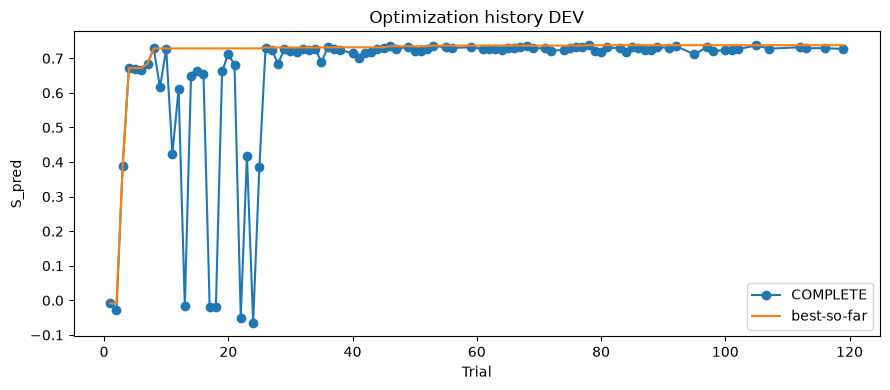

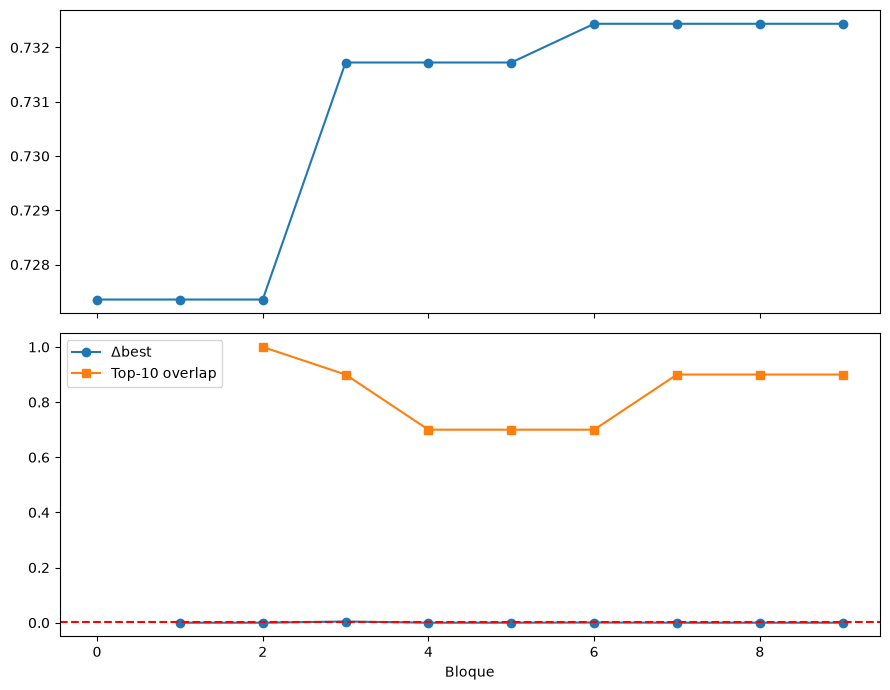

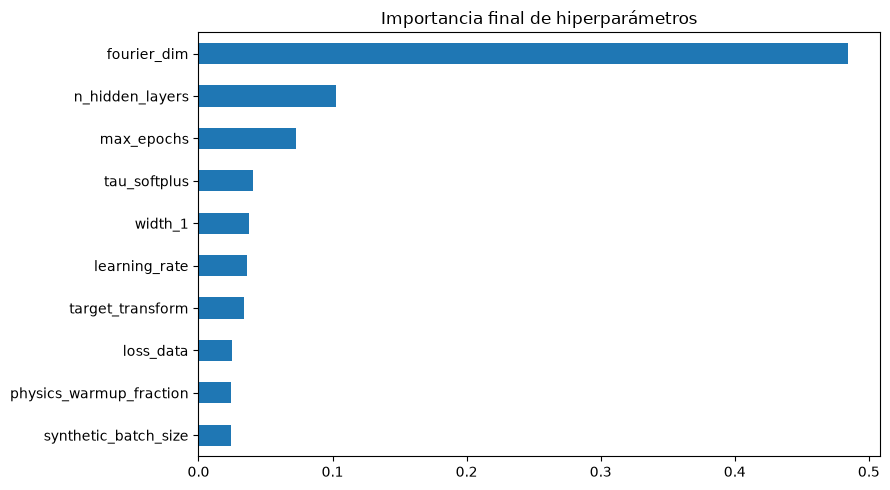

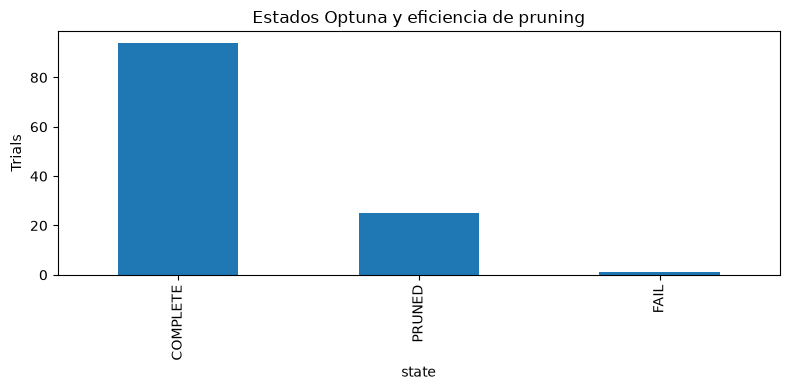

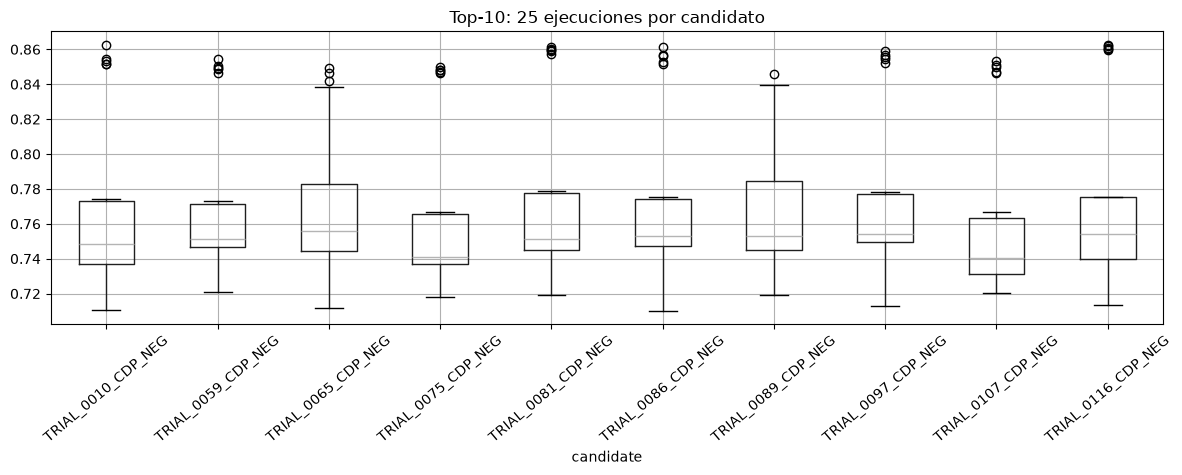

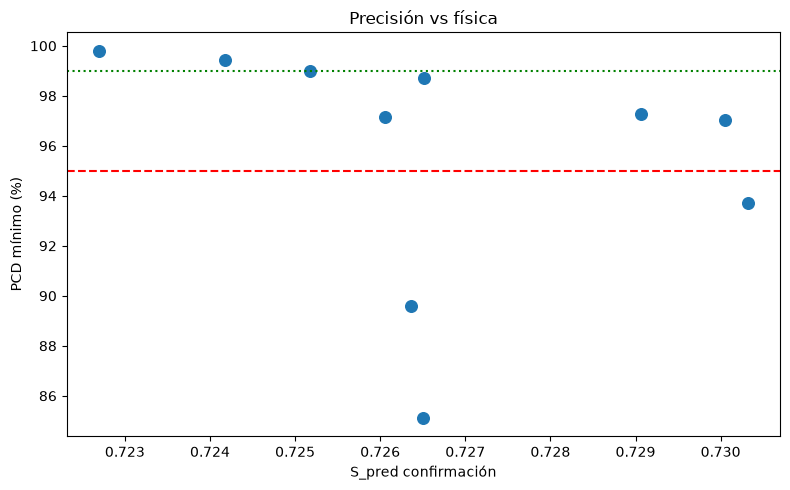

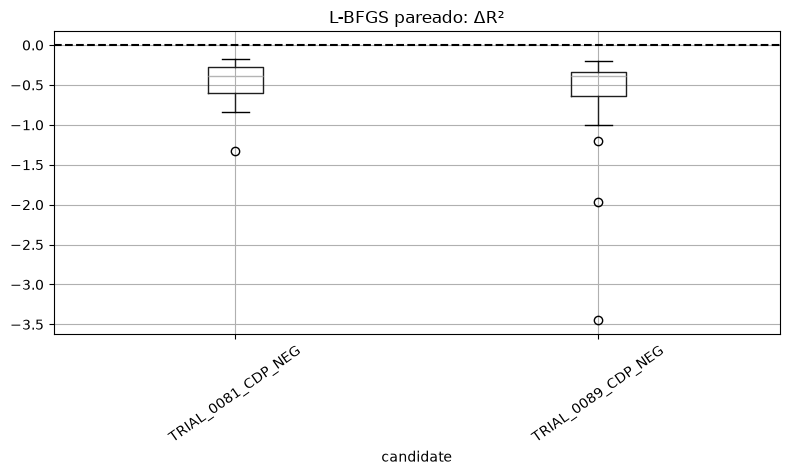

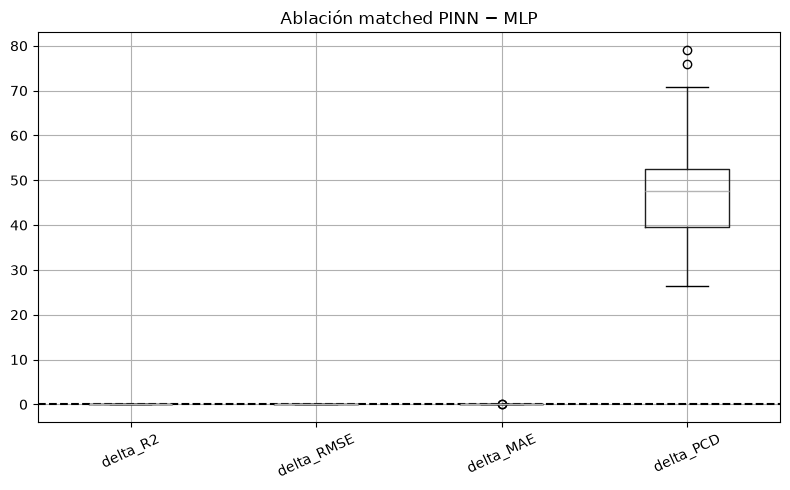

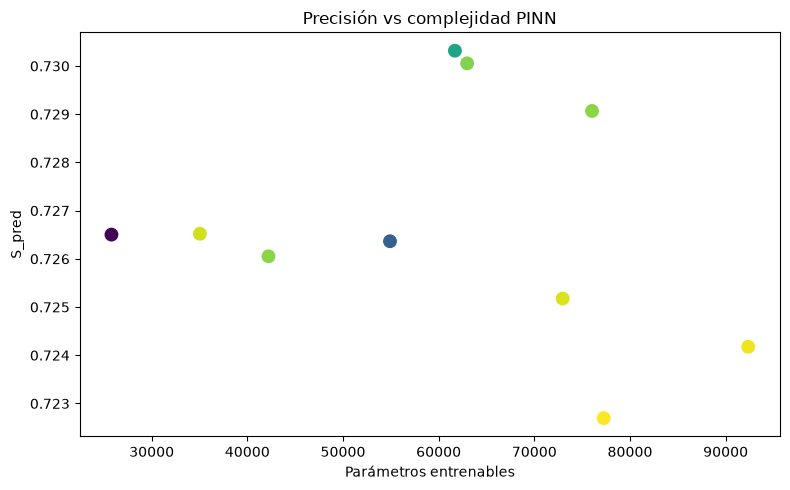

,resultado
version,CO_INTERP_OPT_R5
status,COMPLETE
run_mode,FULL_AUTO
updated_at,2026-08-26T03:21:52.170107+00:00
protocol_status,FROZEN
upstream_notebook,00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb
upstream_protocol_rel,models\interp\work_pinn_interp_protocol
authorized_direct_consumer,04_Gold_Standard_PINN_CO_INTERP_FINAL - R5F_ST...
output_rel,models\interp\work_pinn_co_interp_opt_r5
lineage_contract_sha256,41dd2d35ba3c59a9383e4afa09992855d498d021ec22cc...


,reanudacion
status,COMPLETE
mode,RESUME_LBFGS_FROM_CHECKPOINT
workers,1
confirmation_rows_before,250
confirmation_rows_after,250
optuna_trials_before,"{'complete': 94, 'pruned': 25, 'fail': 1, 'run..."
optuna_trials_after,"{'complete': 94, 'pruned': 25, 'fail': 1, 'run..."
adaptive_stop_reason,STOP_ADAPTIVE_STABILIZATION
stable_streak,3
test_opened,False


In [56]:
# [C-12.01] RESUME_CONFIRMATION_ONLY — cinco trabajadores
# Esta celda no invoca run_development, study.optimize ni run_smoke.
RUN_STARTED = time.perf_counter()

phase_before_resume = json.loads((PATHS.work / "campaign_phase_state.json").read_text(encoding="utf-8"))
expected_counts = {
    "complete": 94, "pruned": 25, "fail": 1,
    "running": 0, "waiting": 0, "attempted": 120,
}
if phase_before_resume.get("phase") != "CONFIRMATION_COMPLETE":
    raise RuntimeError(f"RESUME_ABORTED_PHASE_MISMATCH: {phase_before_resume}")
if int(phase_before_resume.get("rows", -1)) != 250:
    raise RuntimeError(f"RESUME_ABORTED_CONFIRMATION_PHASE_ROWS: {phase_before_resume}")
if phase_before_resume.get("test_opened") is not False:
    raise RuntimeError("RESUME_ABORTED_TEST_BARRIER")

protocol_tag = PROTOCOL_STATUS["assignment_sha256"][:12]
study_name = f"CO_INTERP_DEVELOPMENT_{CAMPAIGN_SCHEMA_VERSION}_{protocol_tag}"
snapshot_db = (
    PATHS.optuna_development
    / f"CO_INTERP_DEVELOPMENT_{CAMPAIGN_SCHEMA_VERSION.lower()}_{protocol_tag}.sqlite3"
)
if not sqlite_integrity_ok(snapshot_db):
    raise RuntimeError(f"RESUME_ABORTED_SQLITE_INTEGRITY: {snapshot_db}")

# Optuna se carga únicamente para recuperar configuraciones y ranking ya cerrados.
STUDY = optuna.load_study(
    study_name=study_name,
    storage=f"sqlite:///{snapshot_db.as_posix()}",
)
TRIAL_COUNTS = trial_state_counts(STUDY)
if TRIAL_COUNTS != expected_counts:
    raise RuntimeError(f"RESUME_ABORTED_TRIAL_COUNTS: {TRIAL_COUNTS}")

adaptive_history = load_adaptive_history()
if adaptive_history.empty:
    raise RuntimeError("RESUME_ABORTED_ADAPTIVE_HISTORY_EMPTY")
adaptive_last = adaptive_history.iloc[-1]
if int(adaptive_last["stable_streak"]) != 3:
    raise RuntimeError(f"RESUME_ABORTED_STABLE_STREAK: {adaptive_last['stable_streak']}")
if adaptive_last["stop_reason"] != "STOP_ADAPTIVE_STABILIZATION":
    raise RuntimeError(f"RESUME_ABORTED_ADAPTIVE_REASON: {adaptive_last['stop_reason']}")

RANKING = ranking_frame(STUDY)
observed_top10 = (
    RANKING.loc[RANKING.physics_admissible]
    .head(TOP_N_CONFIRMATION)
    .trial_number.astype(int).tolist()
)
expected_top10 = [89, 59, 81, 97, 65, 75, 116, 86, 107, 10]
if observed_top10 != expected_top10:
    raise RuntimeError(f"RESUME_ABORTED_TOP10: {observed_top10}")

confirmation_path = PATHS.tables / "CONFIRMATION_RUNS_CO_R5.csv"
confirmation_before = pd.read_csv(confirmation_path)
if len(confirmation_before) != 250:
    raise RuntimeError(f"RESUME_ABORTED_CONFIRMATION_ROWS: {len(confirmation_before)}")

print({
    "mode": "RESUME_LBFGS_FROM_CHECKPOINT",
    "workers": PARALLEL_WORKERS,
    "optuna_trials_before": TRIAL_COUNTS,
    "confirmation_rows_preserved": len(confirmation_before),
    "next_expected_work": "evaluate trials 89/81 checkpoints; fallback FO trial 97",
    "test_opened": False,
})

RESULT = confirmation_and_freeze(STUDY, RANKING)
RESULT["trial_counts"] = TRIAL_COUNTS
RESULT["stop_reason"] = "STOP_ADAPTIVE_STABILIZATION"
plot_campaign(STUDY, RANKING, RESULT)

counts_after = trial_state_counts(STUDY)
if counts_after != expected_counts:
    raise RuntimeError(f"OPTUNA_MUTATED_DURING_RESUME: {counts_after}")

RUN_ELAPSED_SECONDS = time.perf_counter() - RUN_STARTED
STATE = persist_campaign_summary(RESULT, RUN_ELAPSED_SECONDS)
RESUME_EVIDENCE = {
    "status": RESULT.get("status"),
    "mode": "RESUME_LBFGS_FROM_CHECKPOINT",
    "workers": PARALLEL_WORKERS,
    "confirmation_rows_before": len(confirmation_before),
    "confirmation_rows_after": len(pd.read_csv(confirmation_path)),
    "optuna_trials_before": TRIAL_COUNTS,
    "optuna_trials_after": counts_after,
    "adaptive_stop_reason": "STOP_ADAPTIVE_STABILIZATION",
    "stable_streak": int(adaptive_last["stable_streak"]),
    "test_opened": False,
    "elapsed_seconds": RUN_ELAPSED_SECONDS,
    "generated_at_utc": utc_now(),
}
atomic_json(PATHS.audit / "RESUME_TRIAL97_LBFGS_FALLBACK_SCIENTIFIC_EVIDENCE_CO_R5.json", RESUME_EVIDENCE)
display(pd.Series(STATE, name="resultado").to_frame())
display(pd.Series(RESUME_EVIDENCE, name="reanudacion").to_frame())


## OUT-06 — Cierre R5

El notebook implementa la especificación congelada R5 para CO: Optuna autónomo,
espacio amplio, física fija `CDP_NEG`, barrera de pruning 2+3, piso dinámico de early
stopping, parada adaptativa 100–200 intentos, Top-10 × 5 × 5, L-BFGS Top-3,
ablación matched, seed representativa por mediana DEV, `FINAL_EPOCHS` por mediana y
handoff verificable. TEST no se abre ni se evalúa en este notebook.
